# Compare YOLO26-seg

## 1. Setup

In [109]:

import warnings
from pathlib import Path
from typing import Iterable

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display, Markdown
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

# ----- estilo global ---------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "legend.fontsize": 10,
})
sns.set_context("notebook", font_scale=1.0)

# ----- paleta por tamanho do modelo (Okabe-Ito) ------------------------------
MODEL_PALETTE = {
    "Nano":   "#56B4E9",
    "Small":  "#0072B2",
    "Medium": "#009E73",
    "Large":  "#E69F00",
    "XLarge": "#D55E00",
}

# ----- paleta por versão (Okabe-Ito; estendida) ------------------------------
VERSION_PALETTE = {
    "v1": "#999999",
    "v2": "#0072B2",
    "v3": "#E69F00",
    "v4": "#56B4E9",
    "v5": "#009E73",
    "v6": "#F0E442",
    "v7": "#D55E00",
    "v8": "#CC79A7",
}

# Specs nominais YOLO26-seg (params em milhões; GFLOPs aproximados)
MODEL_SPECS = {
    "Nano":   {"params_m":  3.4, "gflops":  10.4},
    "Small":  {"params_m": 11.4, "gflops":  37.1},
    "Medium": {"params_m": 25.9, "gflops":  98.9},
    "Large":  {"params_m": 43.7, "gflops": 165.7},
    "XLarge": {"params_m": 68.2, "gflops": 257.8},
}

MODEL_ORDER_FULL = ["Nano", "Small", "Medium", "Large", "XLarge"]

SUCCESS = "#2A9D8F"
DANGER  = "#E63946"
NEUTRAL = "#6C757D"

print("Setup OK")


Setup OK


### 1.1 Configuração principal — `VERSIONS` (edite aqui)

Cada entrada combina:
- `log_dir` → diretório-raiz dos logs daquela versão
- `model_dirs` → mapa `tamanho → nome da pasta com `results.csv` + `args.yaml`

Para **adicionar uma versão**, copie um bloco e ajuste paths. Para **remover**, comente as linhas. O notebook detecta automaticamente runs ausentes e os omite das tabelas/plots.

In [110]:

# Mude `unb_server` conforme o ambiente.
unb_server = True

if unb_server:
    BASE_DIR = Path("/home/antoniovinicius/projects/sandbox_yolo26")
else:
    BASE_DIR = Path("/home/avmoura_linux/Documents/unb/sandbox_yolo26")

# ============================================================================
# DICIONÁRIO DE VERSÕES — comente/descomente conforme necessário
# ============================================================================
VERSIONS = {
    "v1": {
        "log_dir": BASE_DIR / "logs" / "train_isic_2018_task_1_v1",
        "model_dirs": {
            "Nano":   "yolo26_nano_ft_isic_2018",
            "Small":  "yolo26_small_ft_isic_2018",
            "Medium": "yolo26_medium_ft_isic_2018",
            "Large":  "yolo26_large_ft_isic_2018",
            "XLarge": "yolo26_xlarge_ft_isic_2018",
        },
    },
    "v2": {
        "log_dir": BASE_DIR / "logs" / "train_isic_2018_task_1_v2",
        "model_dirs": {
            "Nano":   "yolo26_nano_ft_isic_2018_v2",
            "Small":  "yolo26_small_ft_isic_2018_v2",
            "Medium": "yolo26_medium_ft_isic_2018_v2",
            "Large":  "yolo26_large_ft_isic_2018_v2",
            "XLarge": "yolo26_xlarge_ft_isic_2018_v2",
        },
    },
    # "v3": {
    #     "log_dir": BASE_DIR / "logs" / "train_isic_2018_task_1_v3",
    #     "model_dirs": {
    #         "Nano":   "yolo26_nano_ft_isic_2018_v3",
    #         "Small":  "yolo26_small_ft_isic_2018_v3",
    #         "Medium": "yolo26_medium_ft_isic_2018_v3",
    #         "Large":  "yolo26_large_ft_isic_2018_v3",
    #         "XLarge": "yolo26_xlarge_ft_isic_2018_v3",
    #     },
    # },
    # "v7": {
    #     "log_dir": BASE_DIR / "logs" / "train_isic_2018_task_1_v7",
    #     "model_dirs": {
    #         "Nano":   "yolo26_nano_ft_isic_2018_v7",
    #         "Small":  "yolo26_small_ft_isic_2018_v7",
    #         "Medium": "yolo26_medium_ft_isic_2018_v7",
    #         "Large":  "yolo26_large_ft_isic_2018_v7",
    #         "XLarge": "yolo26_xlarge_ft_isic_2018_v7",
    #     },
    # },
    "v8": {
        "log_dir": BASE_DIR / "logs" / "train_isic_2018_task_1_v8",
        "model_dirs": {
            "Nano":   "yolo26_nano_ft_isic_2018_v8",
            "Small":  "yolo26_small_ft_isic_2018_v8",
            "Medium": "yolo26_medium_ft_isic_2018_v8",
            "Large":  "yolo26_large_ft_isic_2018_v8",
            "XLarge": "yolo26_xlarge_ft_isic_2018_v8",
        },
    },
}

VERSION_ORDER = list(VERSIONS.keys())

# Sanity check
print(f"{'Version':<8}{'Model':<8}{'Status':<10}Path")
print("-" * 90)
for v, cfg in VERSIONS.items():
    for m, d in cfg["model_dirs"].items():
        p = cfg["log_dir"] / d
        status = "[OK]" if p.exists() else "[MISSING]"
        print(f"{v:<8}{m:<8}{status:<10}{p}")


Version Model   Status    Path
------------------------------------------------------------------------------------------
v1      Nano    [OK]      /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v1/yolo26_nano_ft_isic_2018
v1      Small   [OK]      /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v1/yolo26_small_ft_isic_2018
v1      Medium  [OK]      /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v1/yolo26_medium_ft_isic_2018
v1      Large   [OK]      /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v1/yolo26_large_ft_isic_2018
v1      XLarge  [OK]      /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v1/yolo26_xlarge_ft_isic_2018
v2      Nano    [OK]      /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v2/yolo26_nano_ft_isic_2018_v2
v2      Small   [OK]      /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v

## 2. Helpers

In [111]:

def smooth(x: np.ndarray, window: int = 5) -> np.ndarray:
    """Centered moving average (NaN-safe)."""
    s = pd.Series(x).rolling(window=window, center=True, min_periods=1).mean()
    return s.to_numpy()


def add_value_labels(ax, fmt: str = "{:.3f}", padding: float = 0.005,
                     fontsize: int = 9) -> None:
    ymin, ymax = ax.get_ylim()
    pad = (ymax - ymin) * padding
    for p in ax.patches:
        h = p.get_height()
        if not np.isfinite(h):
            continue
        ax.annotate(
            fmt.format(h),
            (p.get_x() + p.get_width() / 2.0, h + pad),
            ha="center", va="bottom", fontsize=fontsize, color="#333",
        )


def epochs_to_threshold(df: pd.DataFrame, col: str, frac: float = 0.95) -> int | float:
    if col not in df or df[col].dropna().empty:
        return np.nan
    target = df[col].max() * frac
    hit = df.loc[df[col] >= target, "epoch"]
    if hit.empty:
        return np.nan
    return int(hit.iloc[0])


def stability(df: pd.DataFrame, col: str, last_n: int = 10) -> float:
    if col not in df:
        return np.nan
    s = df[col].dropna().tail(last_n)
    return float(s.std()) if not s.empty else np.nan


def overfit_gap(df: pd.DataFrame, best_idx: int, train_col: str,
                val_col: str) -> float:
    try:
        return float(df.loc[best_idx, val_col] - df.loc[best_idx, train_col])
    except (KeyError, IndexError):
        return np.nan


print("Helpers ready")


Helpers ready


## 3. Carga de dados

In [112]:

def extract_summary(version: str, model_name: str, results_dir: Path) -> dict | None:
    rcsv = results_dir / "results.csv"
    if not rcsv.exists():
        return None
    df = pd.read_csv(rcsv)
    df.columns = [c.strip() for c in df.columns]

    if "metrics/mAP50-95(M)" not in df:
        return None

    best_idx = df["metrics/mAP50-95(M)"].idxmax()
    best = df.loc[best_idx]

    args_path = results_dir / "args.yaml"
    args = {}
    if args_path.exists():
        try:
            args = yaml.safe_load(args_path.read_text()) or {}
        except yaml.YAMLError:
            args = {}

    if "lr/pg0" in df:
        lr = df["lr/pg0"]
        n = len(lr)
        lr_start = float(lr.iloc[: max(1, n // 10)].mean())
        lr_mid   = float(lr.iloc[n // 3: 2 * n // 3].mean())
        lr_end   = float(lr.iloc[-max(1, n // 10):].mean())
    else:
        lr_start = lr_mid = lr_end = np.nan

    return {
        "Version": version,
        "Model": model_name,
        "Params (M)": MODEL_SPECS.get(model_name, {}).get("params_m", np.nan),
        "GFLOPs":     MODEL_SPECS.get(model_name, {}).get("gflops",   np.nan),
        # Mask
        "Mask mAP@50":    float(best.get("metrics/mAP50(M)",     np.nan)),
        "Mask mAP@50-95": float(best.get("metrics/mAP50-95(M)",  np.nan)),
        "Mask Precision": float(best.get("metrics/precision(M)", np.nan)),
        "Mask Recall":    float(best.get("metrics/recall(M)",    np.nan)),
        # BBox
        "BBox mAP@50":    float(best.get("metrics/mAP50(B)",     np.nan)),
        "BBox mAP@50-95": float(best.get("metrics/mAP50-95(B)",  np.nan)),
        # Loss / time / convergência
        "Best epoch":      int(best.get("epoch", -1)),
        "Train time (min)": float(df["time"].max()) / 60.0 if "time" in df else np.nan,
        "Val seg_loss":    float(best.get("val/seg_loss", np.nan)),
        "Val box_loss":    float(best.get("val/box_loss", np.nan)),
        "Train seg_loss":  float(best.get("train/seg_loss", np.nan)),
        "Train box_loss":  float(best.get("train/box_loss", np.nan)),
        "Overfit gap (seg)": overfit_gap(df, best_idx, "train/seg_loss", "val/seg_loss"),
        "Overfit gap (box)": overfit_gap(df, best_idx, "train/box_loss", "val/box_loss"),
        "Eps to 95% best": epochs_to_threshold(df, "metrics/mAP50-95(M)", 0.95),
        "Eps to 99% best": epochs_to_threshold(df, "metrics/mAP50-95(M)", 0.99),
        "Stability (std last10)": stability(df, "metrics/mAP50-95(M)", last_n=10),
        # LR effective
        "lr/pg0 start": lr_start,
        "lr/pg0 mid":   lr_mid,
        "lr/pg0 end":   lr_end,
        # Hp (do args.yaml)
        "optimizer":    args.get("optimizer"),
        "lr0":          args.get("lr0"),
        "amp":          args.get("amp"),
        "batch":        args.get("batch"),
        "epochs (cfg)": args.get("epochs"),
        "close_mosaic": args.get("close_mosaic"),
        "erasing":      args.get("erasing"),
        "weight_decay": args.get("weight_decay"),
        "dropout":      args.get("dropout"),
        # Refs ao DataFrame bruto p/ as curvas
        "_df":          df,
        "_args":        args,
        "_results_dir": results_dir,
    }


# Loop versions × sizes
rows = []
missing = []
for v, cfg in VERSIONS.items():
    for m in MODEL_ORDER_FULL:
        if m not in cfg["model_dirs"]:
            continue
        rdir = cfg["log_dir"] / cfg["model_dirs"][m]
        s = extract_summary(v, m, rdir)
        if s is None:
            missing.append((v, m, rdir))
        else:
            rows.append(s)

if not rows:
    raise FileNotFoundError(
        "Nenhum results.csv carregado — verifique o dict VERSIONS na §1.1."
    )

df_long = pd.DataFrame(rows)

VERSIONS_PRESENT = [v for v in VERSION_ORDER if v in df_long["Version"].unique()]
MODELS_PRESENT   = [m for m in MODEL_ORDER_FULL if m in df_long["Model"].unique()]

print(f"Carregados: {len(df_long)} runs ({len(VERSIONS_PRESENT)} versões × até {len(MODELS_PRESENT)} tamanhos)")
print(f"Versões presentes: {VERSIONS_PRESENT}")
print(f"Tamanhos presentes: {MODELS_PRESENT}")
if missing:
    print(f"\n[skip] {len(missing)} runs não encontrados:")
    for v, m, p in missing:
        print(f"  {v:<6}{m:<8}{p}")


Carregados: 15 runs (3 versões × até 5 tamanhos)
Versões presentes: ['v1', 'v2', 'v8']
Tamanhos presentes: ['Nano', 'Small', 'Medium', 'Large', 'XLarge']


## 4. Resumo executivo

In [113]:

best_row = df_long.loc[df_long["Mask mAP@50-95"].idxmax()]
display(Markdown(
    f"### 🏆 Champion global: **{best_row['Version']} · {best_row['Model']}** "
    f"(Mask mAP@50-95 = **{best_row['Mask mAP@50-95']:.4f}** @ ep {best_row['Best epoch']})"
))

display(Markdown("### 4.1 Métricas principais — todas as combinações"))
main_cols = ["Mask mAP@50", "Mask mAP@50-95", "BBox mAP@50", "BBox mAP@50-95",
             "Mask Precision", "Mask Recall"]

pivot_main = df_long.set_index(["Version", "Model"])[main_cols]
pivot_main = pivot_main.reindex(
    pd.MultiIndex.from_product([VERSIONS_PRESENT, MODELS_PRESENT],
                               names=["Version", "Model"])
)


def highlight_max_per_col(s: pd.Series):
    is_max = s == s.max()
    return [
        f"background-color: {SUCCESS}; color: white; font-weight: 600" if v else ""
        for v in is_max
    ]


display(pivot_main.style.apply(highlight_max_per_col, axis=0)
        .format("{:.4f}", na_rep="—")
        .set_caption("Verde = melhor combinação para cada métrica"))


display(Markdown("### 4.2 Champion por versão (a melhor de cada coluna `Mask mAP@50-95`)"))
champ_per_v = (
    df_long.sort_values("Mask mAP@50-95", ascending=False)
    .groupby("Version", as_index=False).first()
    [["Version", "Model", "Mask mAP@50-95", "Mask mAP@50",
      "Best epoch", "Train time (min)", "Params (M)"]]
    .set_index("Version").reindex(VERSIONS_PRESENT)
)
display(champ_per_v.style.format({
    "Mask mAP@50-95":   "{:.4f}",
    "Mask mAP@50":      "{:.4f}",
    "Best epoch":       "{:.0f}",
    "Train time (min)": "{:.1f}",
    "Params (M)":       "{:.1f}",
}).background_gradient(subset=["Mask mAP@50-95"], cmap="YlGn"))


### 🏆 Champion global: **v8 · Small** (Mask mAP@50-95 = **0.7315** @ ep 9)

### 4.1 Métricas principais — todas as combinações

### 4.2 Champion por versão (a melhor de cada coluna `Mask mAP@50-95`)

,Model,Mask mAP@50-95,Mask mAP@50,Best epoch,Train time (min),Params (M)
Version,,,,,,
v1,Medium,0.7275,0.9794,99,113.8,25.9
v2,Nano,0.7283,0.9641,37,49.1,3.4
v8,Small,0.7315,0.9597,9,17.5,11.4


## 5. Performance principal — grouped bars (size × version)

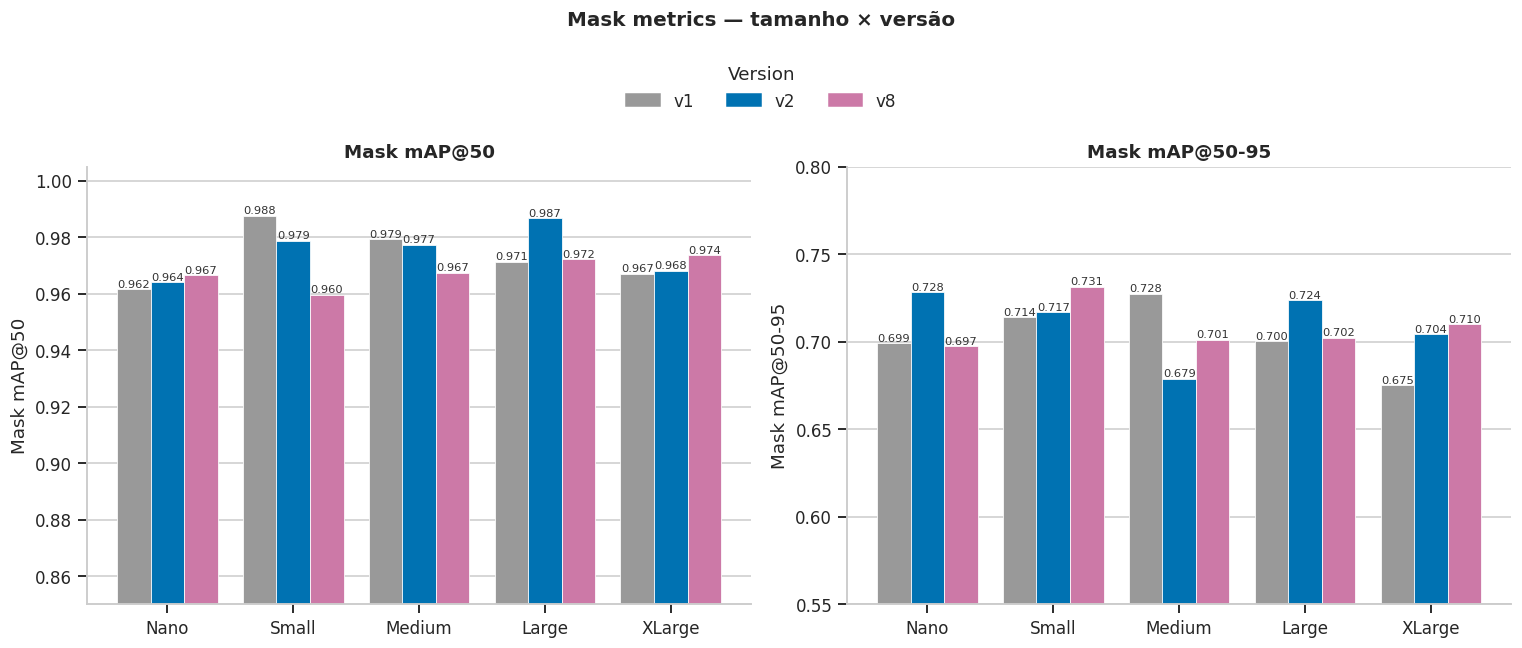

In [114]:

def grouped_bar(ax, value_col: str, title: str, ylim=None, fmt="{:.3f}"):
    """X = Model size, hue = Version."""
    pivot = (
        df_long.pivot_table(index="Model", columns="Version",
                            values=value_col, aggfunc="first")
        .reindex(index=MODELS_PRESENT, columns=VERSIONS_PRESENT)
    )
    n_versions = len(VERSIONS_PRESENT)
    n_models   = len(MODELS_PRESENT)
    x = np.arange(n_models)
    width = 0.8 / max(n_versions, 1)

    for j, v in enumerate(VERSIONS_PRESENT):
        offset = (j - (n_versions - 1) / 2) * width
        vals = pivot[v].values
        bars = ax.bar(x + offset, vals, width=width,
                      color=VERSION_PALETTE.get(v, "#888"),
                      edgecolor="white", linewidth=0.5,
                      label=v)
        # value labels
        for xi, h in zip(x + offset, vals):
            if np.isfinite(h):
                ax.annotate(fmt.format(h), (xi, h),
                            ha="center", va="bottom", fontsize=7.5, color="#333")

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS_PRESENT, rotation=0)
    ax.set_title(title)
    ax.set_ylabel(value_col)
    ax.set_xlabel("")
    if ylim:
        ax.set_ylim(*ylim)
    ax.grid(axis="x", visible=False)


# ---- Mask -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
grouped_bar(axes[0], "Mask mAP@50",    "Mask mAP@50",    ylim=(0.85, 1.005))
grouped_bar(axes[1], "Mask mAP@50-95", "Mask mAP@50-95", ylim=(0.55, 0.80))

handles = [Patch(color=VERSION_PALETTE.get(v, "#888"), label=v) for v in VERSIONS_PRESENT]
fig.legend(handles=handles, title="Version", loc="upper center",
           bbox_to_anchor=(0.5, 1.06), ncol=len(VERSIONS_PRESENT))
fig.suptitle("Mask metrics — tamanho × versão", y=1.13, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


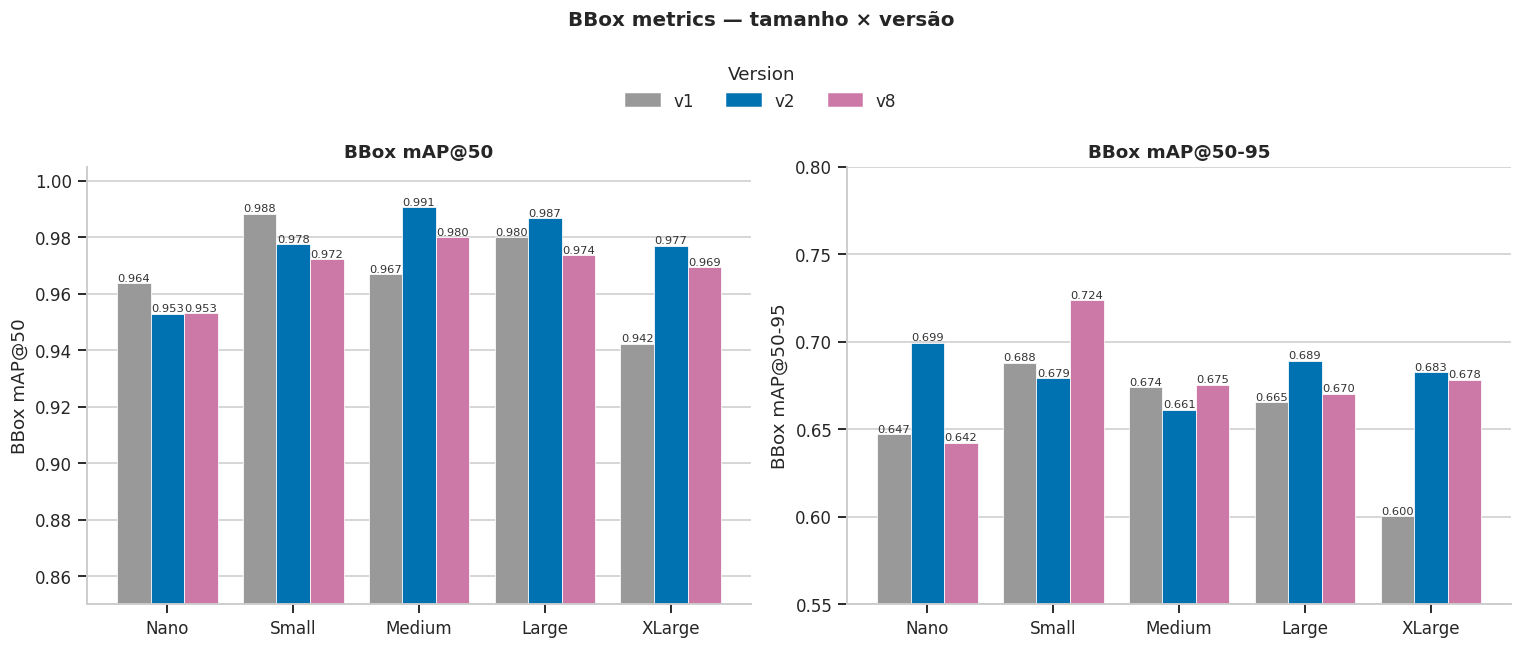

In [115]:

# ---- BBox -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
grouped_bar(axes[0], "BBox mAP@50",    "BBox mAP@50",    ylim=(0.85, 1.005))
grouped_bar(axes[1], "BBox mAP@50-95", "BBox mAP@50-95", ylim=(0.55, 0.80))

handles = [Patch(color=VERSION_PALETTE.get(v, "#888"), label=v) for v in VERSIONS_PRESENT]
fig.legend(handles=handles, title="Version", loc="upper center",
           bbox_to_anchor=(0.5, 1.06), ncol=len(VERSIONS_PRESENT))
fig.suptitle("BBox metrics — tamanho × versão", y=1.13, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Métricas operacionais

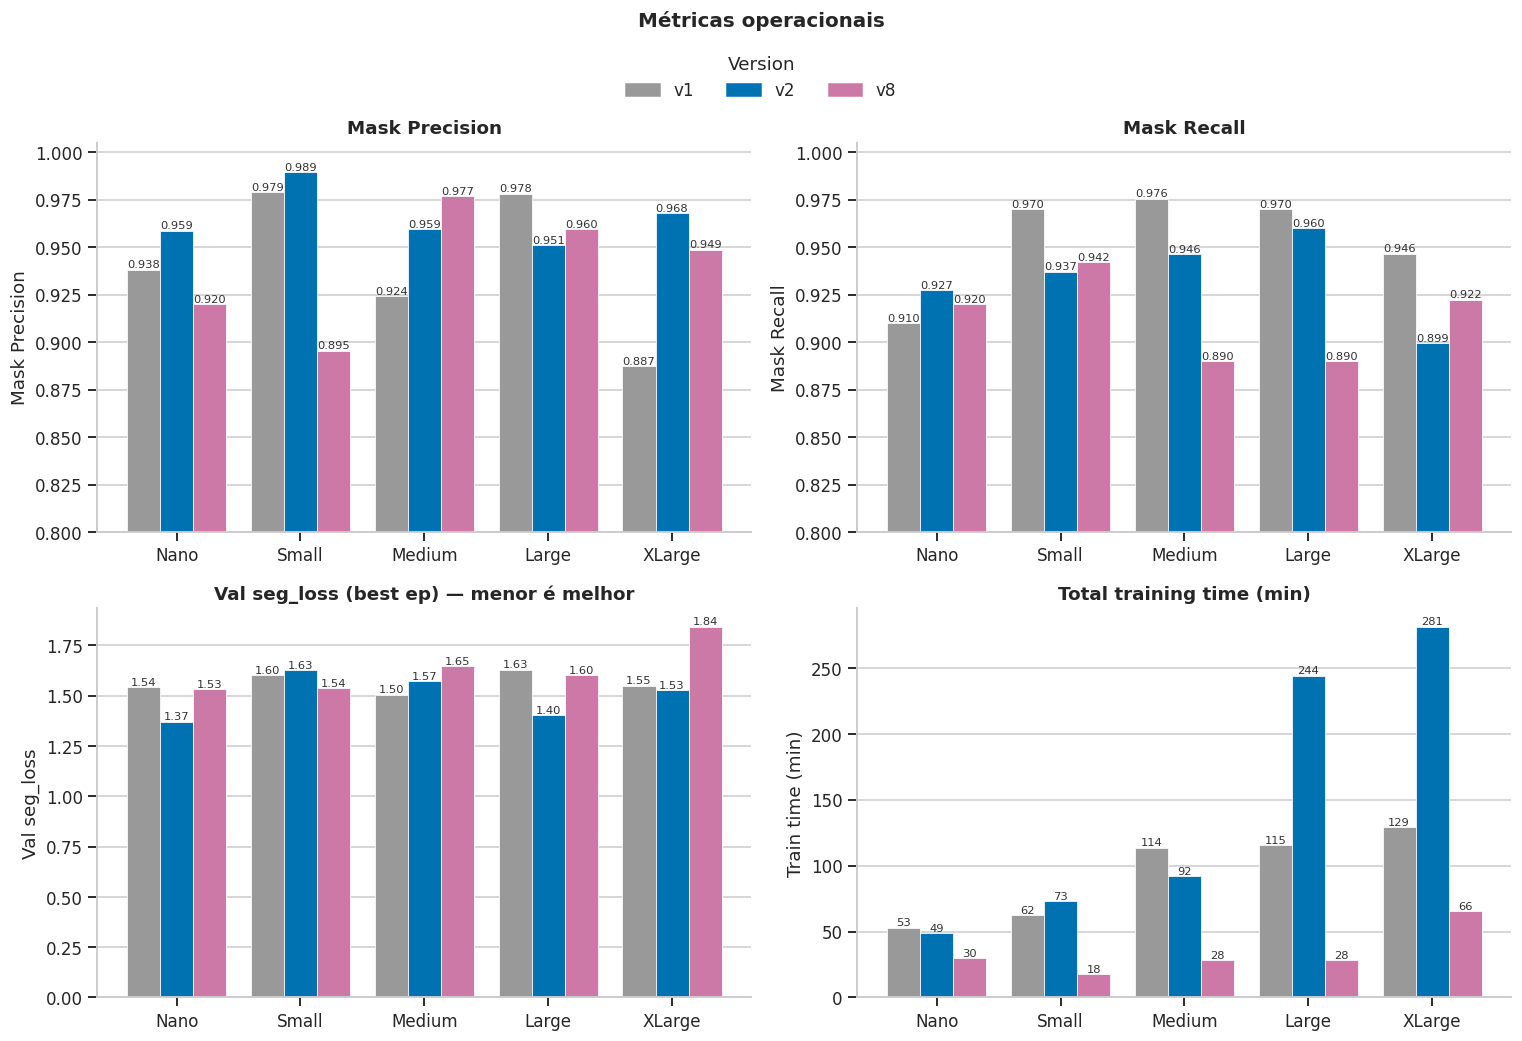

In [116]:

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
grouped_bar(axes[0, 0], "Mask Precision",   "Mask Precision",   ylim=(0.80, 1.005))
grouped_bar(axes[0, 1], "Mask Recall",      "Mask Recall",      ylim=(0.80, 1.005))
grouped_bar(axes[1, 0], "Val seg_loss",     "Val seg_loss (best ep) — menor é melhor", fmt="{:.2f}")
grouped_bar(axes[1, 1], "Train time (min)", "Total training time (min)", fmt="{:.0f}")

handles = [Patch(color=VERSION_PALETTE.get(v, "#888"), label=v) for v in VERSIONS_PRESENT]
fig.legend(handles=handles, title="Version", loc="upper center",
           bbox_to_anchor=(0.5, 1.02), ncol=len(VERSIONS_PRESENT))
fig.suptitle("Métricas operacionais", y=1.05, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Robustez geométrica — `mAP@50-95 / mAP@50`

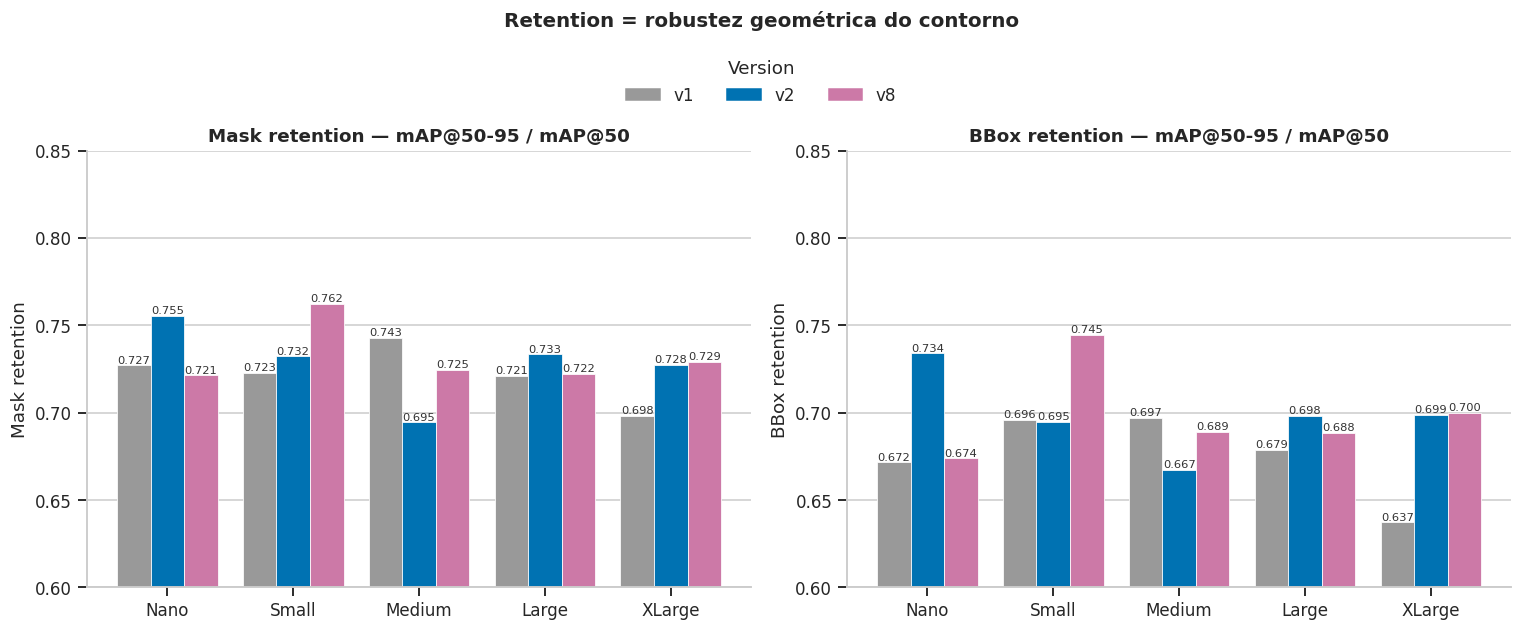

In [117]:

df_long["Mask retention"] = df_long["Mask mAP@50-95"] / df_long["Mask mAP@50"]
df_long["BBox retention"] = df_long["BBox mAP@50-95"] / df_long["BBox mAP@50"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
grouped_bar(axes[0], "Mask retention",
            "Mask retention — mAP@50-95 / mAP@50", ylim=(0.60, 0.85), fmt="{:.3f}")
grouped_bar(axes[1], "BBox retention",
            "BBox retention — mAP@50-95 / mAP@50", ylim=(0.60, 0.85), fmt="{:.3f}")

handles = [Patch(color=VERSION_PALETTE.get(v, "#888"), label=v) for v in VERSIONS_PRESENT]
fig.legend(handles=handles, title="Version", loc="upper center",
           bbox_to_anchor=(0.5, 1.04), ncol=len(VERSIONS_PRESENT))
fig.suptitle("Retention = robustez geométrica do contorno", y=1.10, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 8. Estabilidade do treino

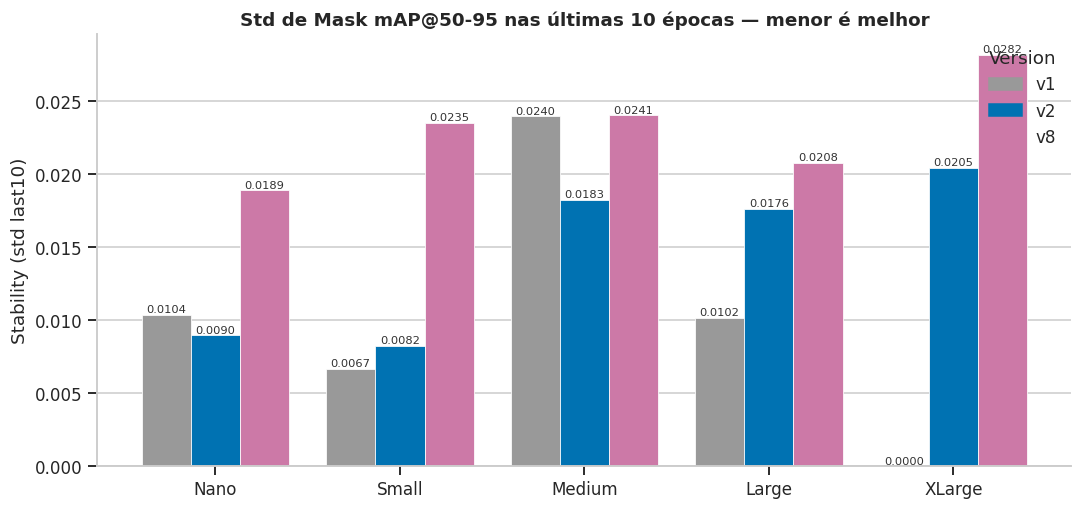

In [118]:

fig, ax = plt.subplots(figsize=(10, 4.8))
grouped_bar(ax, "Stability (std last10)",
            "Std de Mask mAP@50-95 nas últimas 10 épocas — menor é melhor",
            fmt="{:.4f}")
handles = [Patch(color=VERSION_PALETTE.get(v, "#888"), label=v) for v in VERSIONS_PRESENT]
ax.legend(handles=handles, title="Version", loc="upper right", ncol=1)
plt.tight_layout()
plt.show()


## 9. Convergência

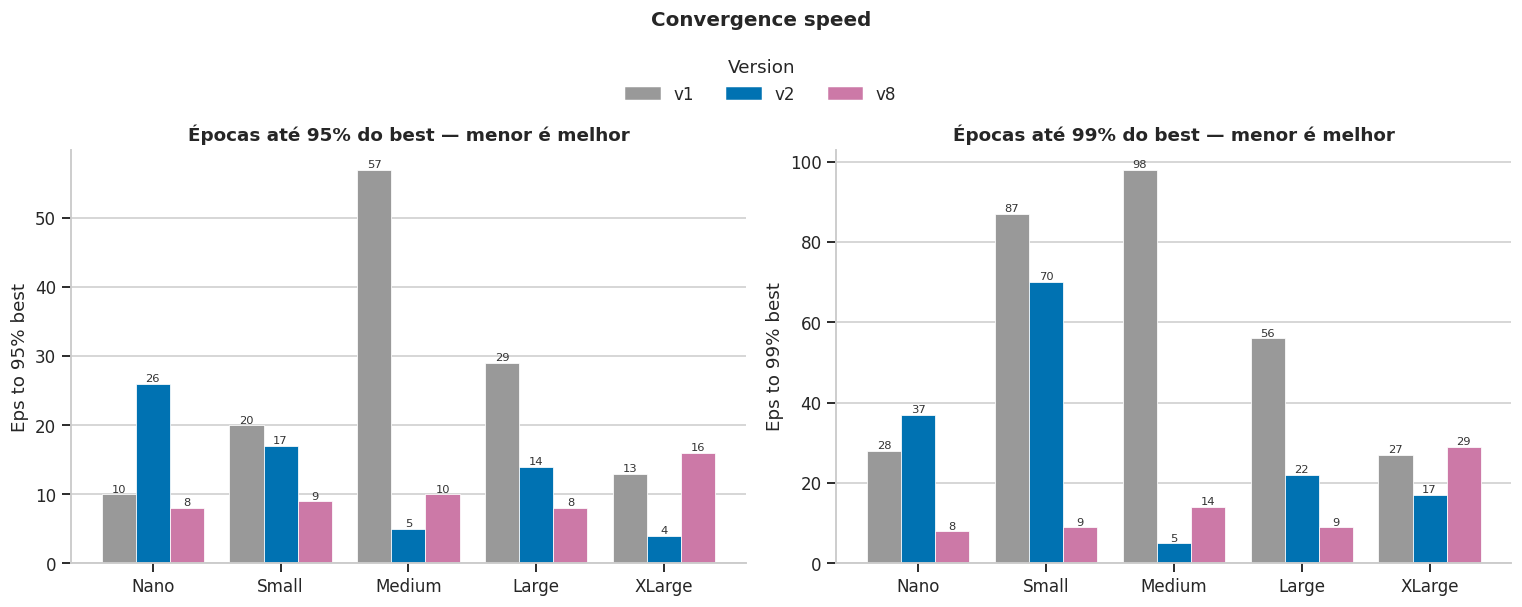

In [119]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
grouped_bar(axes[0], "Eps to 95% best", "Épocas até 95% do best — menor é melhor", fmt="{:.0f}")
grouped_bar(axes[1], "Eps to 99% best", "Épocas até 99% do best — menor é melhor", fmt="{:.0f}")

handles = [Patch(color=VERSION_PALETTE.get(v, "#888"), label=v) for v in VERSIONS_PRESENT]
fig.legend(handles=handles, title="Version", loc="upper center",
           bbox_to_anchor=(0.5, 1.04), ncol=len(VERSIONS_PRESENT))
fig.suptitle("Convergence speed", y=1.10, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Curvas de treino — Mask mAP@50-95 e val/seg_loss
Facetas por **versão**; cores por **tamanho** dentro de cada subplot.

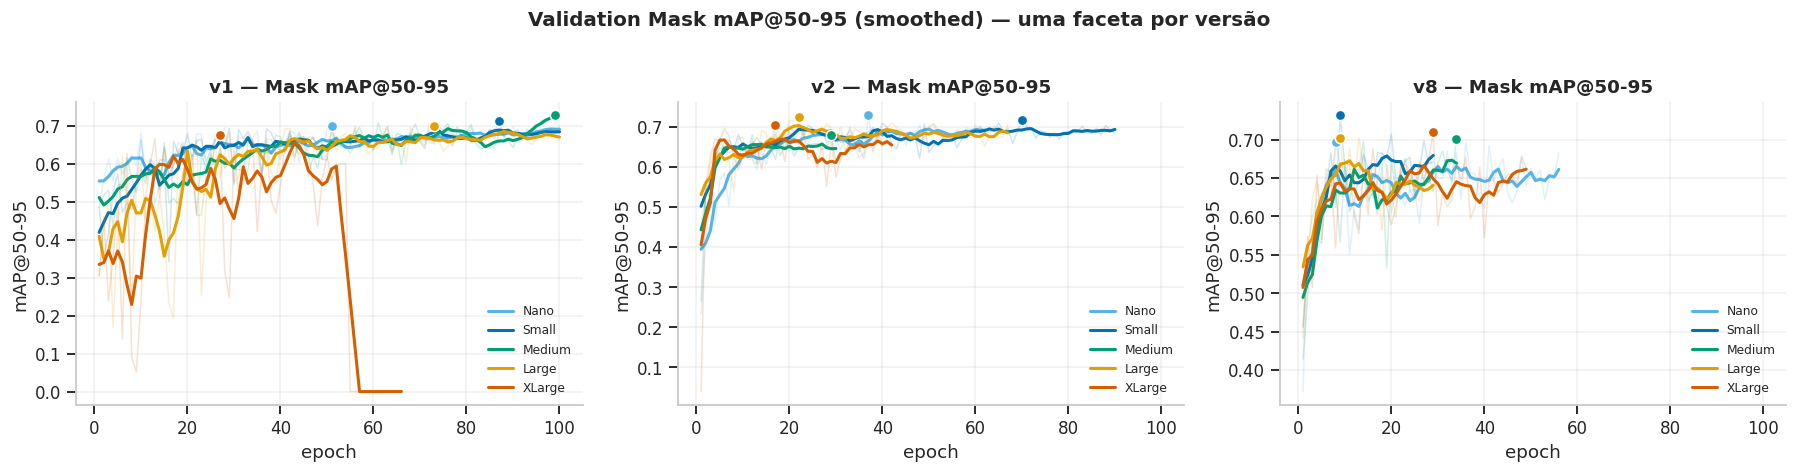

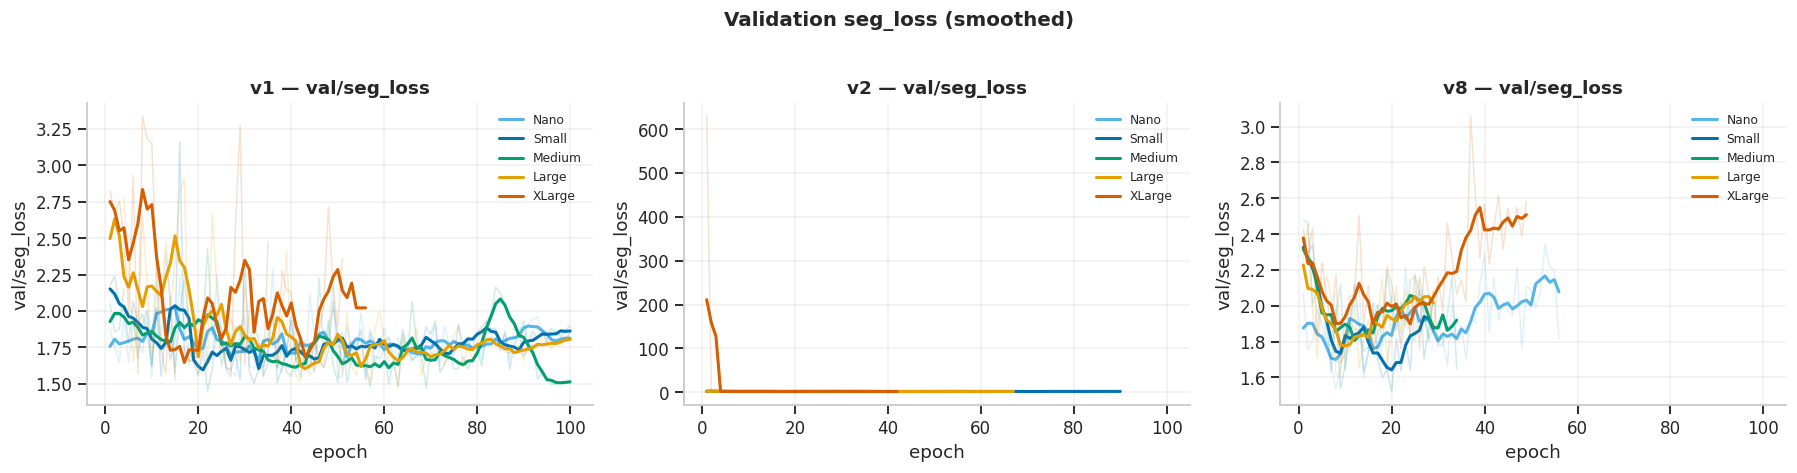

In [120]:

WINDOW = 5
nv = len(VERSIONS_PRESENT)
ncols = min(3, max(1, nv))
nrows = int(np.ceil(nv / ncols))

# (a) Mask mAP@50-95 ----------------------------------------------------------
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.2 * nrows),
                         squeeze=False, sharex=True)
axes_flat = axes.flatten()
for i, v in enumerate(VERSIONS_PRESENT):
    ax = axes_flat[i]
    sub = df_long[df_long["Version"] == v]
    for _, r in sub.iterrows():
        df = r["_df"]; m = r["Model"]
        if "metrics/mAP50-95(M)" not in df:
            continue
        eps = df["epoch"].to_numpy()
        y = df["metrics/mAP50-95(M)"].to_numpy()
        c = MODEL_PALETTE[m]
        ax.plot(eps, y, color=c, alpha=0.18, lw=1)
        ax.plot(eps, smooth(y, WINDOW), color=c, lw=2.0, label=m)
        b = int(np.argmax(y))
        ax.scatter([eps[b]], [y[b]], color=c, s=45, zorder=5,
                   edgecolor="white", lw=1.0)
    ax.set_title(f"{v} — Mask mAP@50-95")
    ax.set_xlabel("epoch"); ax.set_ylabel("mAP@50-95")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=8)

for j in range(nv, len(axes_flat)):
    axes_flat[j].axis("off")
fig.suptitle("Validation Mask mAP@50-95 (smoothed) — uma faceta por versão",
             y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# (b) val/seg_loss ------------------------------------------------------------
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.2 * nrows),
                         squeeze=False, sharex=True)
axes_flat = axes.flatten()
for i, v in enumerate(VERSIONS_PRESENT):
    ax = axes_flat[i]
    sub = df_long[df_long["Version"] == v]
    for _, r in sub.iterrows():
        df = r["_df"]; m = r["Model"]
        if "val/seg_loss" not in df:
            continue
        eps = df["epoch"].to_numpy()
        y = df["val/seg_loss"].to_numpy()
        c = MODEL_PALETTE[m]
        ax.plot(eps, y, color=c, alpha=0.18, lw=1)
        ax.plot(eps, smooth(y, WINDOW), color=c, lw=2.0, label=m)
    ax.set_title(f"{v} — val/seg_loss")
    ax.set_xlabel("epoch"); ax.set_ylabel("val/seg_loss")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

for j in range(nv, len(axes_flat)):
    axes_flat[j].axis("off")
fig.suptitle("Validation seg_loss (smoothed)",
             y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 11. Train vs Val seg_loss — overfitting check
Grade `(versão × tamanho)` — train (sólido) vs val (tracejado).

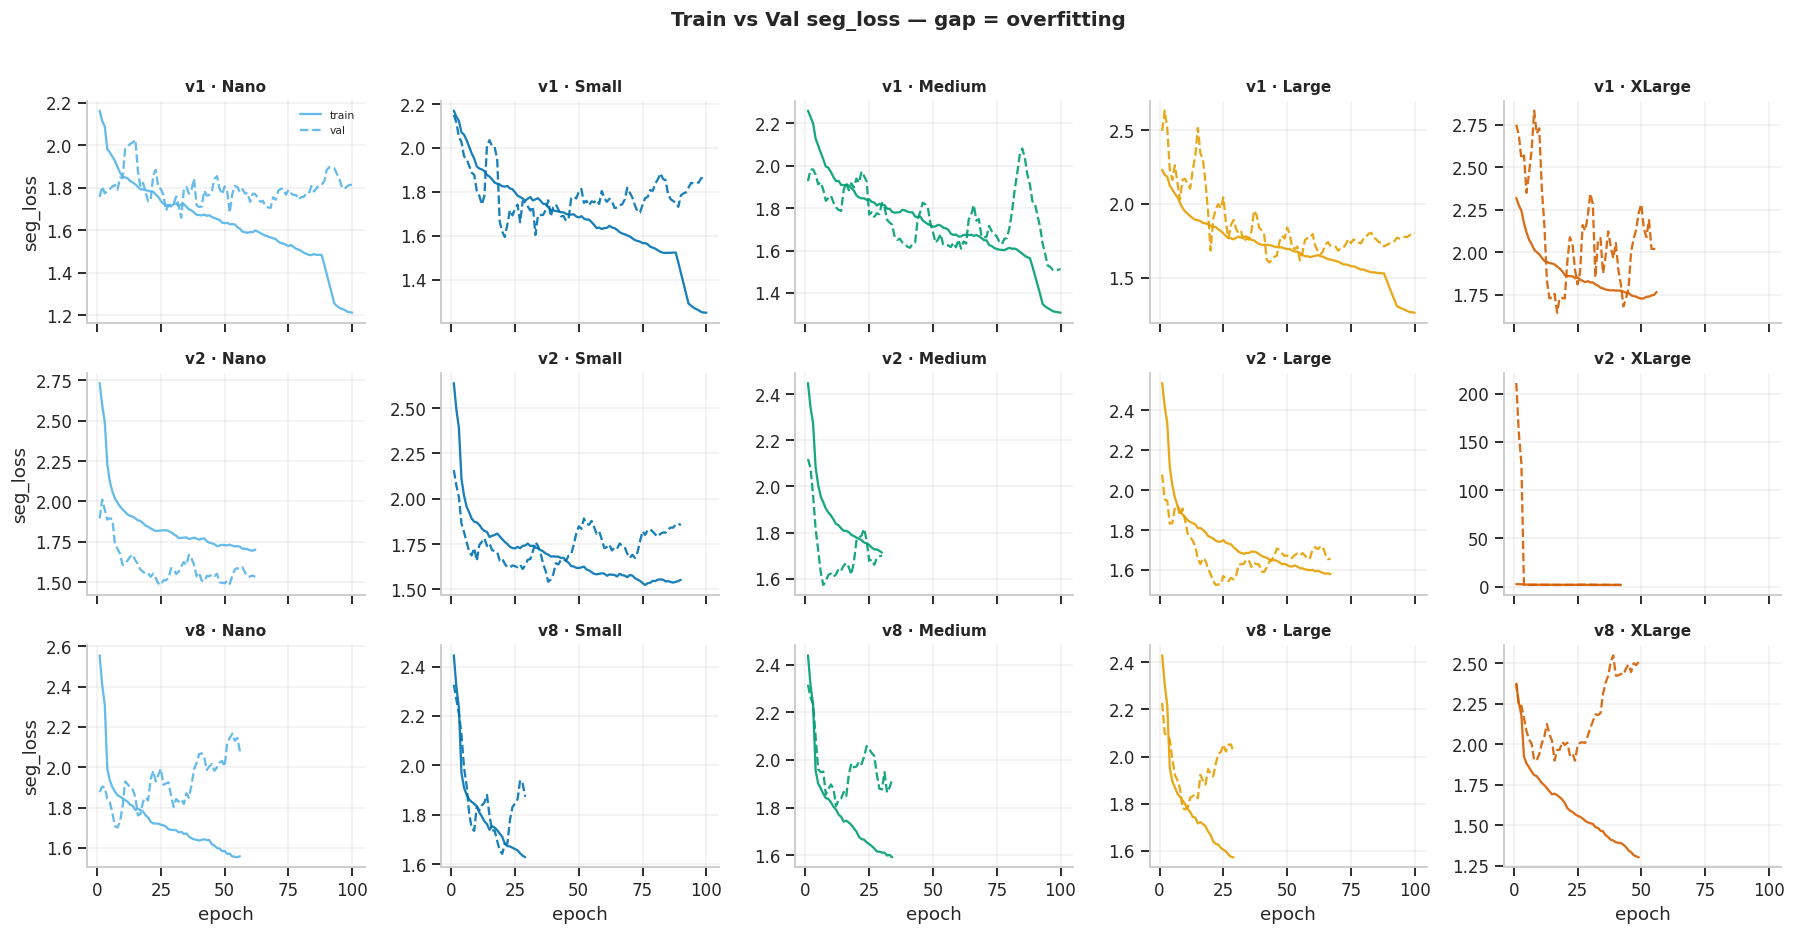

### Overfit gap (val − train seg_loss no best ep)

Version,v1,v2,v8
Model,,,
Nano,-0.074,-0.414,-0.309
Small,+0.071,+0.051,-0.306
Medium,+0.196,-0.140,+0.079
Large,+0.061,-0.319,-0.203
XLarge,-0.287,-0.331,+0.303


In [121]:

nv = len(VERSIONS_PRESENT)
nm = len(MODELS_PRESENT)
fig, axes = plt.subplots(nv, nm, figsize=(3.3 * nm, 2.8 * nv),
                         squeeze=False, sharex=True)

for i, v in enumerate(VERSIONS_PRESENT):
    for j, m in enumerate(MODELS_PRESENT):
        ax = axes[i, j]
        sel = df_long[(df_long["Version"] == v) & (df_long["Model"] == m)]
        if sel.empty:
            ax.axis("off"); continue
        df = sel.iloc[0]["_df"]
        if "train/seg_loss" not in df or "val/seg_loss" not in df:
            ax.axis("off"); continue
        eps = df["epoch"].to_numpy()
        c = MODEL_PALETTE[m]
        ax.plot(eps, smooth(df["train/seg_loss"].to_numpy(), 5),
                color=c, lw=1.5, alpha=0.9, label="train")
        ax.plot(eps, smooth(df["val/seg_loss"].to_numpy(), 5),
                color=c, lw=1.5, alpha=0.9, ls="--", label="val")
        ax.set_title(f"{v} · {m}", fontsize=10)
        ax.grid(True, alpha=0.3)
        if i == nv - 1:
            ax.set_xlabel("epoch")
        if j == 0:
            ax.set_ylabel("seg_loss")
        if i == 0 and j == 0:
            ax.legend(loc="upper right", fontsize=7)

fig.suptitle("Train vs Val seg_loss — gap = overfitting",
             y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# Tabela: overfit gap
display(Markdown("### Overfit gap (val − train seg_loss no best ep)"))
gap_pivot = (
    df_long.pivot_table(index="Model", columns="Version",
                        values="Overfit gap (seg)", aggfunc="first")
    .reindex(index=MODELS_PRESENT, columns=VERSIONS_PRESENT)
)
display(gap_pivot.style.format("{:+.3f}", na_rep="—")
        .background_gradient(cmap="RdYlGn_r"))


## 12. LR efetivo (`lr/pg0` no meio do treino)

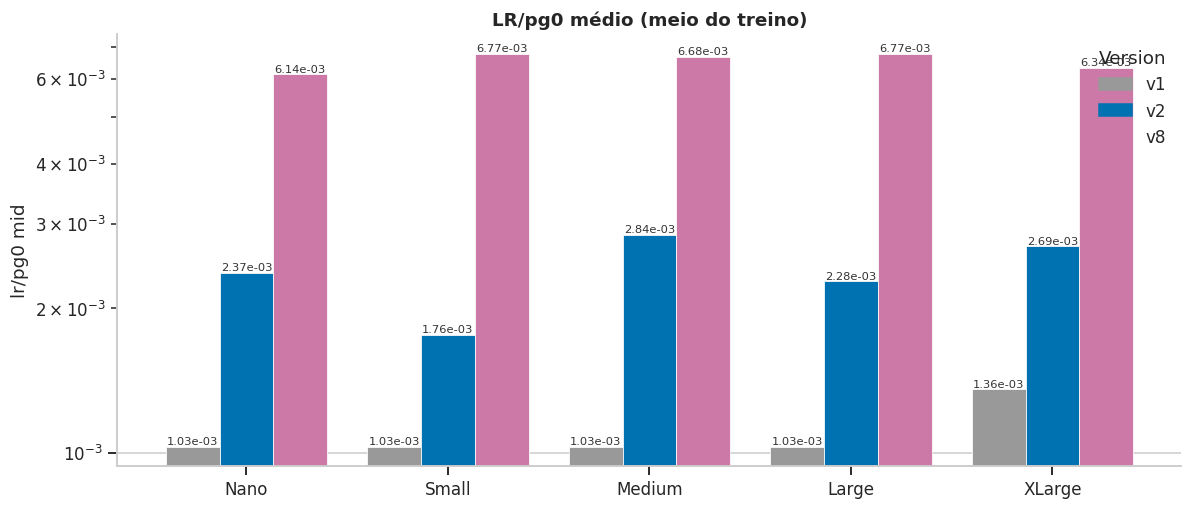

### LR diagnostics (start / mid / end) — `Version · Model`

In [122]:

fig, ax = plt.subplots(figsize=(11, 4.8))
grouped_bar(ax, "lr/pg0 mid", "LR/pg0 médio (meio do treino)", fmt="{:.2e}")
ax.set_yscale("log")
handles = [Patch(color=VERSION_PALETTE.get(v, "#888"), label=v) for v in VERSIONS_PRESENT]
ax.legend(handles=handles, title="Version", loc="upper right", ncol=1)
plt.tight_layout()
plt.show()

display(Markdown("### LR diagnostics (start / mid / end) — `Version · Model`"))
lr_tab = df_long.set_index(["Version", "Model"])[["lr/pg0 start", "lr/pg0 mid", "lr/pg0 end"]]
lr_tab = lr_tab.reindex(
    pd.MultiIndex.from_product([VERSIONS_PRESENT, MODELS_PRESENT],
                               names=["Version", "Model"])
)
display(lr_tab.style.format("{:.2e}", na_rep="—"))


## 13. Scaling: `mAP@50-95` × tamanho do modelo
Uma linha por versão ligando os 5 tamanhos. Eixo X em log (params).

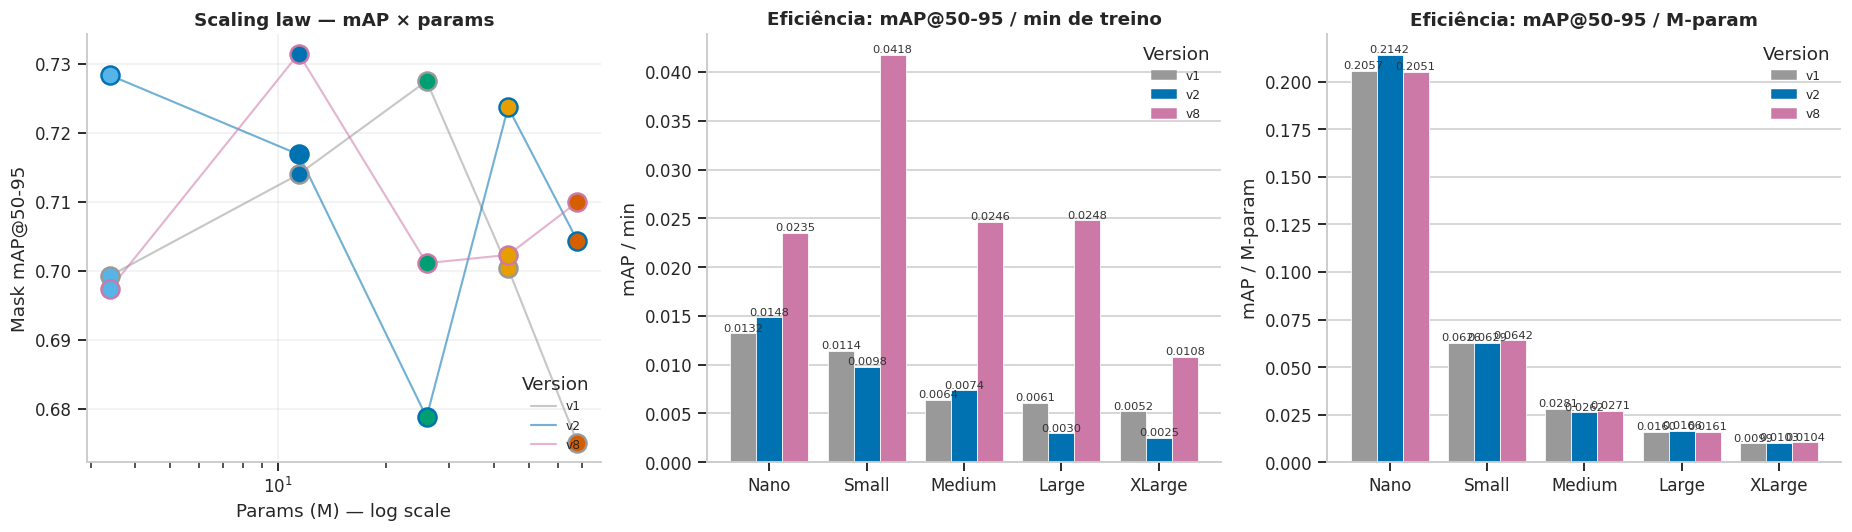

In [123]:

df_long["mAP / min"]      = df_long["Mask mAP@50-95"] / df_long["Train time (min)"]
df_long["mAP / M-param"]  = df_long["Mask mAP@50-95"] / df_long["Params (M)"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) mAP vs params (log) — uma linha por versão -----------------------------
ax = axes[0]
for v in VERSIONS_PRESENT:
    sub = df_long[df_long["Version"] == v].dropna(
        subset=["Params (M)", "Mask mAP@50-95"]
    ).sort_values("Params (M)")
    if sub.empty:
        continue
    color = VERSION_PALETTE.get(v, "#888")
    ax.plot(sub["Params (M)"], sub["Mask mAP@50-95"], "-",
            color=color, alpha=0.55, lw=1.4, zorder=1, label=v)
    for _, r in sub.iterrows():
        ax.scatter(r["Params (M)"], r["Mask mAP@50-95"],
                   s=140, color=MODEL_PALETTE[r["Model"]],
                   edgecolor=color, lw=1.6, zorder=2)
ax.set_xscale("log")
ax.set_xlabel("Params (M) — log scale")
ax.set_ylabel("Mask mAP@50-95")
ax.set_title("Scaling law — mAP × params")
ax.legend(title="Version", loc="lower right", fontsize=8)
ax.grid(True, alpha=0.3)

# (b) mAP / min (eficiência por tempo) ----------------------------------------
ax = axes[1]
grouped_bar(ax, "mAP / min", "Eficiência: mAP@50-95 / min de treino", fmt="{:.4f}")
handles = [Patch(color=VERSION_PALETTE.get(v, "#888"), label=v) for v in VERSIONS_PRESENT]
ax.legend(handles=handles, title="Version", loc="upper right", ncol=1, fontsize=8)

# (c) mAP / M-param (eficiência por parâmetro) --------------------------------
ax = axes[2]
grouped_bar(ax, "mAP / M-param", "Eficiência: mAP@50-95 / M-param", fmt="{:.4f}")
ax.legend(handles=handles, title="Version", loc="upper right", ncol=1, fontsize=8)

plt.tight_layout()
plt.show()


## 14. Pareto: `mAP@50-95` × `Train time`
Marker color = tamanho · marker shape (border) = versão.

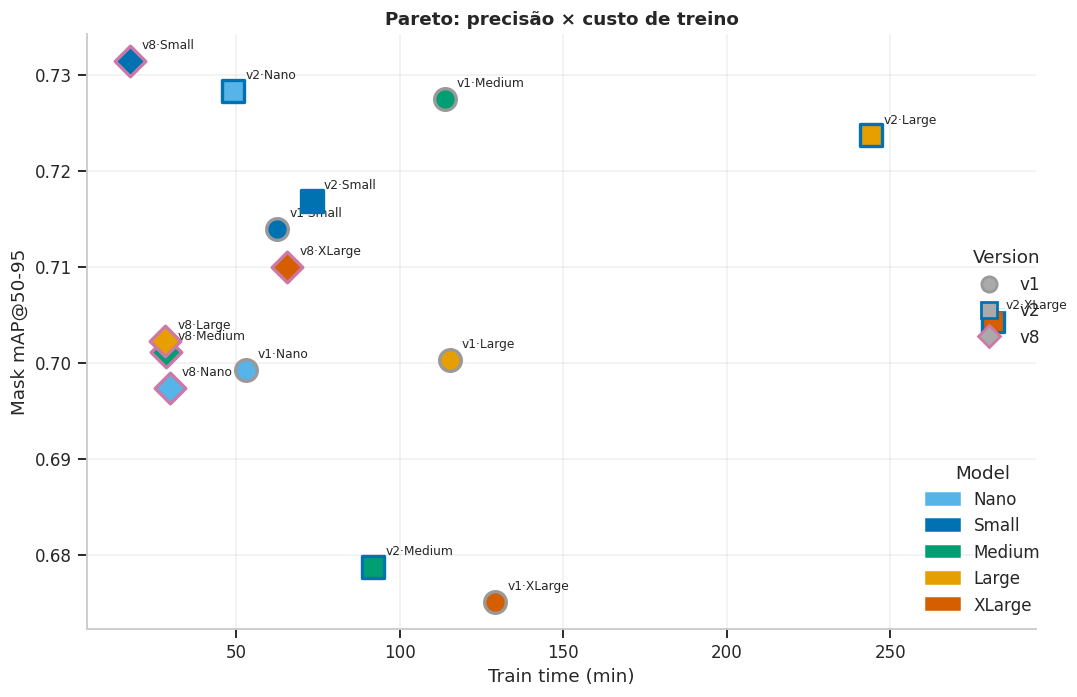

In [124]:

fig, ax = plt.subplots(figsize=(10, 6.5))

# diferentes shapes para cada versão
SHAPE_BY_VERSION = ["o", "s", "D", "^", "v", "P", "X", "*"]
shape_map = {v: SHAPE_BY_VERSION[i % len(SHAPE_BY_VERSION)]
             for i, v in enumerate(VERSIONS_PRESENT)}

for _, r in df_long.iterrows():
    ax.scatter(r["Train time (min)"], r["Mask mAP@50-95"],
               s=200, color=MODEL_PALETTE[r["Model"]],
               edgecolor=VERSION_PALETTE.get(r["Version"], "#444"),
               linewidth=2.2, marker=shape_map[r["Version"]], zorder=3)
    ax.annotate(f"{r['Version']}·{r['Model']}",
                (r["Train time (min)"], r["Mask mAP@50-95"]),
                xytext=(8, 8), textcoords="offset points", fontsize=8)

# Pareto frontier global
pf = df_long.dropna(subset=["Train time (min)", "Mask mAP@50-95"]).sort_values("Train time (min)")
front = []; best_y = -np.inf
for _, r in pf.iterrows():
    if r["Mask mAP@50-95"] > best_y:
        front.append((r["Train time (min)"], r["Mask mAP@50-95"]))
        best_y = r["Mask mAP@50-95"]
if len(front) >= 2:
    fx, fy = zip(*front)
    ax.plot(fx, fy, color=NEUTRAL, ls="--", lw=1.4, alpha=0.7, label="Pareto frontier")

# Legendas combinadas
size_handles = [Patch(color=MODEL_PALETTE[m], label=m) for m in MODELS_PRESENT]
ver_handles  = [
    plt.Line2D([0], [0], marker=shape_map[v], color="w",
               markerfacecolor="#aaa",
               markeredgecolor=VERSION_PALETTE.get(v, "#444"),
               markeredgewidth=1.8, markersize=10, label=v)
    for v in VERSIONS_PRESENT
]
leg1 = ax.legend(handles=size_handles, title="Model", loc="lower right",
                 bbox_to_anchor=(1.02, 0.0))
ax.add_artist(leg1)
ax.legend(handles=ver_handles, title="Version", loc="lower right",
          bbox_to_anchor=(1.02, 0.45))

ax.set_xlabel("Train time (min)")
ax.set_ylabel("Mask mAP@50-95")
ax.set_title("Pareto: precisão × custo de treino")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Diff de hiperparâmetros entre runs
Útil para verificar se as versões diferem no esperado, e os tamanhos **dentro** de cada versão são consistentes.

In [125]:

hp_cols = ["optimizer", "lr0", "amp", "batch", "epochs (cfg)",
           "close_mosaic", "erasing", "weight_decay", "dropout"]

hp = df_long.set_index(["Version", "Model"])[hp_cols].T
hp = hp.reindex(
    columns=pd.MultiIndex.from_product([VERSIONS_PRESENT, MODELS_PRESENT],
                                       names=["Version", "Model"])
)


def style_diff_row(row: pd.Series):
    """Highlight cells that differ from the first non-NaN value of the row."""
    if row.dropna().empty:
        return ["" for _ in row]
    ref = row.dropna().iloc[0]
    return [
        "background-color: #FFF3CD" if (pd.notna(v) and str(v) != str(ref)) else ""
        for v in row
    ]


display(Markdown("### Hiperparâmetros chave"))
display(hp.style.apply(style_diff_row, axis=1)
        .set_caption("Amarelo = difere do primeiro run da linha"))


### Hiperparâmetros chave

## 16. Insights automáticos

In [126]:

insights = []

# 1. Champion global
champ = df_long.loc[df_long["Mask mAP@50-95"].idxmax()]
insights.append(
    f"**Champion global**: `{champ['Version']} · {champ['Model']}` com "
    f"Mask mAP@50-95 = **{champ['Mask mAP@50-95']:.4f}** (best ep {champ['Best epoch']})."
)

# 2. Champion por tamanho
display(Markdown("**Champion por tamanho:**"))
champ_per_m = (
    df_long.sort_values("Mask mAP@50-95", ascending=False)
    .groupby("Model", as_index=False).first()
    [["Model", "Version", "Mask mAP@50-95", "Best epoch"]]
    .set_index("Model").reindex(MODELS_PRESENT)
)
display(champ_per_m.style.format({"Mask mAP@50-95": "{:.4f}", "Best epoch": "{:.0f}"})
        .background_gradient(subset=["Mask mAP@50-95"], cmap="YlGn"))

# 3. Best efficiency
eff_train = df_long.dropna(subset=["mAP / min"])
if not eff_train.empty:
    e = eff_train.loc[eff_train["mAP / min"].idxmax()]
    insights.append(
        f"**Mais eficiente em tempo**: `{e['Version']} · {e['Model']}` "
        f"({e['mAP / min']:.4f} mAP@50-95 / min)."
    )

eff_p = df_long.dropna(subset=["mAP / M-param"])
if not eff_p.empty:
    e = eff_p.loc[eff_p["mAP / M-param"].idxmax()]
    insights.append(
        f"**Mais eficiente em parâmetros**: `{e['Version']} · {e['Model']}` "
        f"({e['mAP / M-param']:.4f} mAP / M-param)."
    )

# 4. Most stable
stab = df_long.dropna(subset=["Stability (std last10)"])
if not stab.empty:
    s = stab.loc[stab["Stability (std last10)"].idxmin()]
    insights.append(
        f"**Mais estável**: `{s['Version']} · {s['Model']}` "
        f"(σ últimas 10 ep = {s['Stability (std last10)']:.4f})."
    )

# 5. Δ entre versões para o mesmo tamanho
if len(VERSIONS_PRESENT) >= 2:
    pivot = (
        df_long.pivot_table(index="Model", columns="Version",
                            values="Mask mAP@50-95", aggfunc="first")
        .reindex(index=MODELS_PRESENT, columns=VERSIONS_PRESENT)
    )
    if pivot.shape[1] >= 2:
        first_v = VERSIONS_PRESENT[0]
        last_v  = VERSIONS_PRESENT[-1]
        deltas = (pivot[last_v] - pivot[first_v]).dropna()
        if not deltas.empty:
            big_winners = deltas[deltas > 0.005]
            big_losers  = deltas[deltas < -0.005]
            if not big_winners.empty:
                lst = ", ".join(f"{m} (Δ={d:+.4f})"
                                for m, d in big_winners.items())
                insights.append(
                    f"**{last_v} vs {first_v} — ganhos**: {lst}."
                )
            if not big_losers.empty:
                lst = ", ".join(f"{m} (Δ={d:+.4f})"
                                for m, d in big_losers.items())
                insights.append(
                    f"**{last_v} vs {first_v} — perdas**: {lst}."
                )

# 6. Diminishing returns dentro de cada versão
for v in VERSIONS_PRESENT:
    sub = df_long[df_long["Version"] == v].dropna(
        subset=["Params (M)", "Mask mAP@50-95"]
    ).sort_values("Params (M)").reset_index(drop=True)
    if len(sub) < 2:
        continue
    deltas = sub["Mask mAP@50-95"].diff()
    bad = deltas[deltas < 0]
    if len(bad):
        idx = bad.index[0]
        prev = sub.iloc[idx - 1]
        cur  = sub.iloc[idx]
        insights.append(
            f"**⚠ Diminishing returns em `{v}`**: `{cur['Model']}` "
            f"({cur['Params (M)']:.1f}M, {cur['Mask mAP@50-95']:.4f}) "
            f"piorou vs `{prev['Model']}` ({prev['Mask mAP@50-95']:.4f})."
        )

# 7. Quality/cost
df_long["Quality/Cost"] = df_long["Mask mAP@50-95"] / np.sqrt(
    df_long["Train time (min)"] * df_long["Params (M)"]
)
qc = df_long.dropna(subset=["Quality/Cost"])
if not qc.empty:
    q = qc.loc[qc["Quality/Cost"].idxmax()]
    insights.append(
        f"**Melhor quality/cost**: `{q['Version']} · {q['Model']}` "
        f"(score = {q['Quality/Cost']:.4f}) — combinação ideal de mAP, "
        "tempo e #params."
    )

display(Markdown("### Insights"))
for s in insights:
    display(Markdown(f"- {s}"))


**Champion por tamanho:**

,Version,Mask mAP@50-95,Best epoch
Model,,,
Nano,v2,0.7283,37
Small,v8,0.7315,9
Medium,v1,0.7275,99
Large,v2,0.7237,22
XLarge,v8,0.7100,29


### Insights

- **Champion global**: `v8 · Small` com Mask mAP@50-95 = **0.7315** (best ep 9).

- **Mais eficiente em tempo**: `v8 · Small` (0.0418 mAP@50-95 / min).

...

- **v8 vs v1 — perdas**: Medium (Δ=-0.0264).

- **⚠ Diminishing returns em `v1`**: `Large` (43.7M, 0.7003) piorou vs `Medium` (0.7275).

- **⚠ Diminishing returns em `v2`**: `Small` (11.4M, 0.7169) piorou vs `Nano` (0.7283).

- **⚠ Diminishing returns em `v8`**: `Medium` (25.9M, 0.7011) piorou vs `Small` (0.7315).

- **Melhor quality/cost**: `v8 · Nano` (score = 0.0695) — combinação ideal de mAP, tempo e #params.

## 18. Inferência qualitativa — comparação visual
Para cada imagem-âncora em `IMAGE_STEMS`, gera **uma figura com a grade `(versão × tamanho)`** mostrando GT (verde) sobreposto à predição (vermelho) e IoU pixel-wise.

**Como configurar**:
1. Edite `IMAGE_STEMS` com nomes (sem extensão) das imagens em `datasets/isic_2018_task1_yolo26/test/images/`.
2. Edite `QUAL_VERSIONS` / `QUAL_MODELS` para selecionar quais combinações comparar (default = todas as carregadas).

In [127]:

IMAGE_STEMS = [
    "ISIC_0017389_jpg.rf.7b4e37a0857a8228ec43b3a669382f92",
    "ISIC_0015169_jpg.rf.cd4b092e76b2b9987890126c3996abef",
    "ISIC_0015970_jpg.rf.696b869a9a5ada775be201c654d87b8c",
    "ISIC_0017434_jpg.rf.5bf254cc1f70130ffa9d4fbbe3b7669e",
    "ISIC_0020081_jpg.rf.975846c0d6c96bafc7af3d96f5aa684d",
    "ISIC_0036343_jpg.rf.155427d08d147b7f7479b26e9833de9c",
]

# Default: todas as combinações carregadas
QUAL_VERSIONS = list(VERSIONS_PRESENT)
QUAL_MODELS   = list(MODELS_PRESENT)

TEST_IMAGES_DIR = BASE_DIR / "datasets" / "isic_2018_task1_yolo26" / "test" / "images"
TEST_LABELS_DIR = BASE_DIR / "datasets" / "isic_2018_task1_yolo26" / "test" / "labels"

# Constrói grid: linhas = versão, colunas = tamanho.
# Cada célula carrega o best.pt correspondente.
QUAL_GRID = {}
for v in QUAL_VERSIONS:
    for m in QUAL_MODELS:
        cfg = VERSIONS.get(v)
        if cfg is None or m not in cfg["model_dirs"]:
            continue
        wpath = cfg["log_dir"] / cfg["model_dirs"][m] / "weights" / "best.pt"
        QUAL_GRID[(v, m)] = wpath

print(f"Eixo: ({len(QUAL_VERSIONS)} versões) × ({len(QUAL_MODELS)} tamanhos) = "
      f"{len(QUAL_GRID)} células")
n_ok = sum(p.exists() for p in QUAL_GRID.values())
print(f"  weights presentes: {n_ok}/{len(QUAL_GRID)}")
print(f"  imagens-âncora:    {len(IMAGE_STEMS)}")
print(f"  test images dir:   {TEST_IMAGES_DIR}",
      "[OK]" if TEST_IMAGES_DIR.exists() else "[MISSING]")


Eixo: (3 versões) × (5 tamanhos) = 15 células
  weights presentes: 15/15
  imagens-âncora:    6
  test images dir:   /home/antoniovinicius/projects/sandbox_yolo26/datasets/isic_2018_task1_yolo26/test/images [OK]


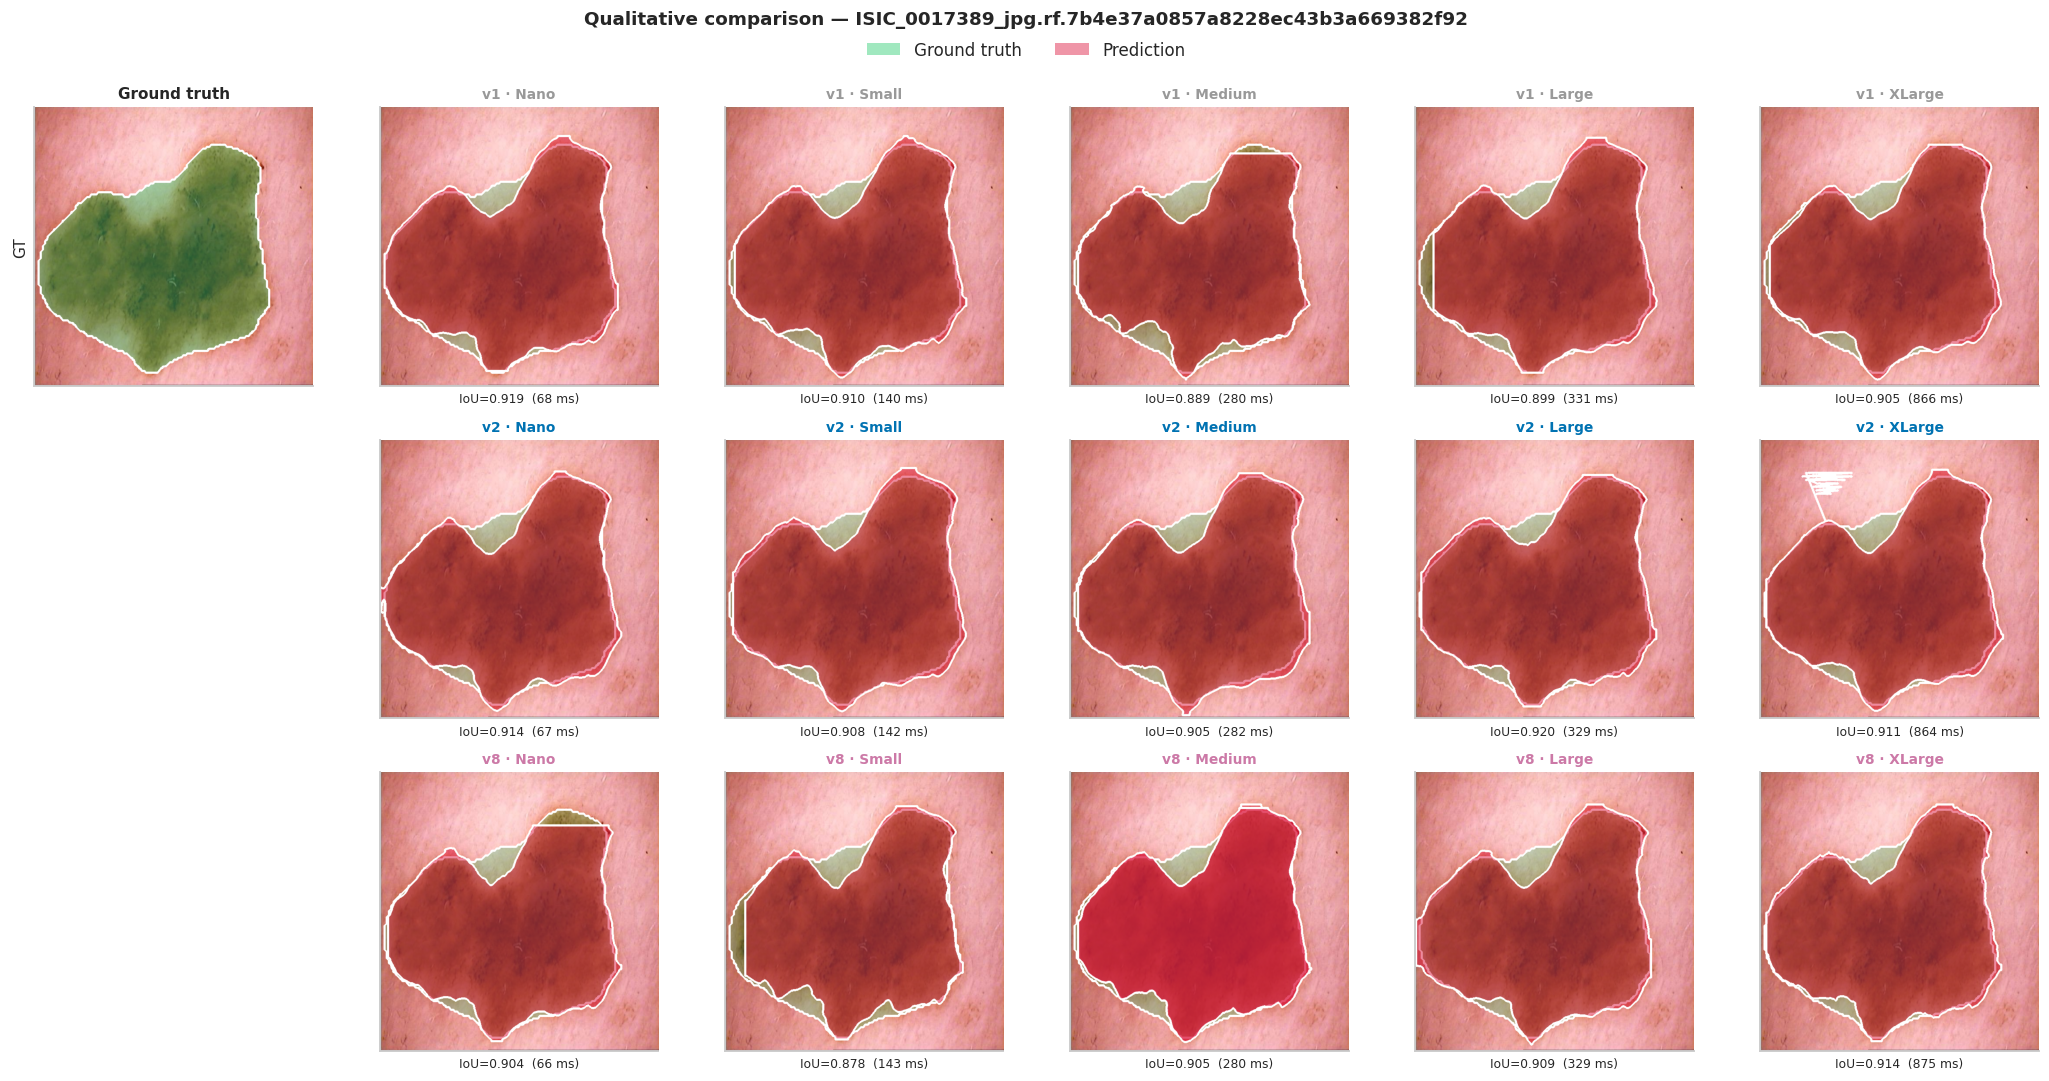

  saved: /home/antoniovinicius/projects/sandbox_yolo26/figures/qualitative/compare_models_ISIC_0017389_jpg.rf.7b4e37a0857a8228ec43b3a669382f92.png


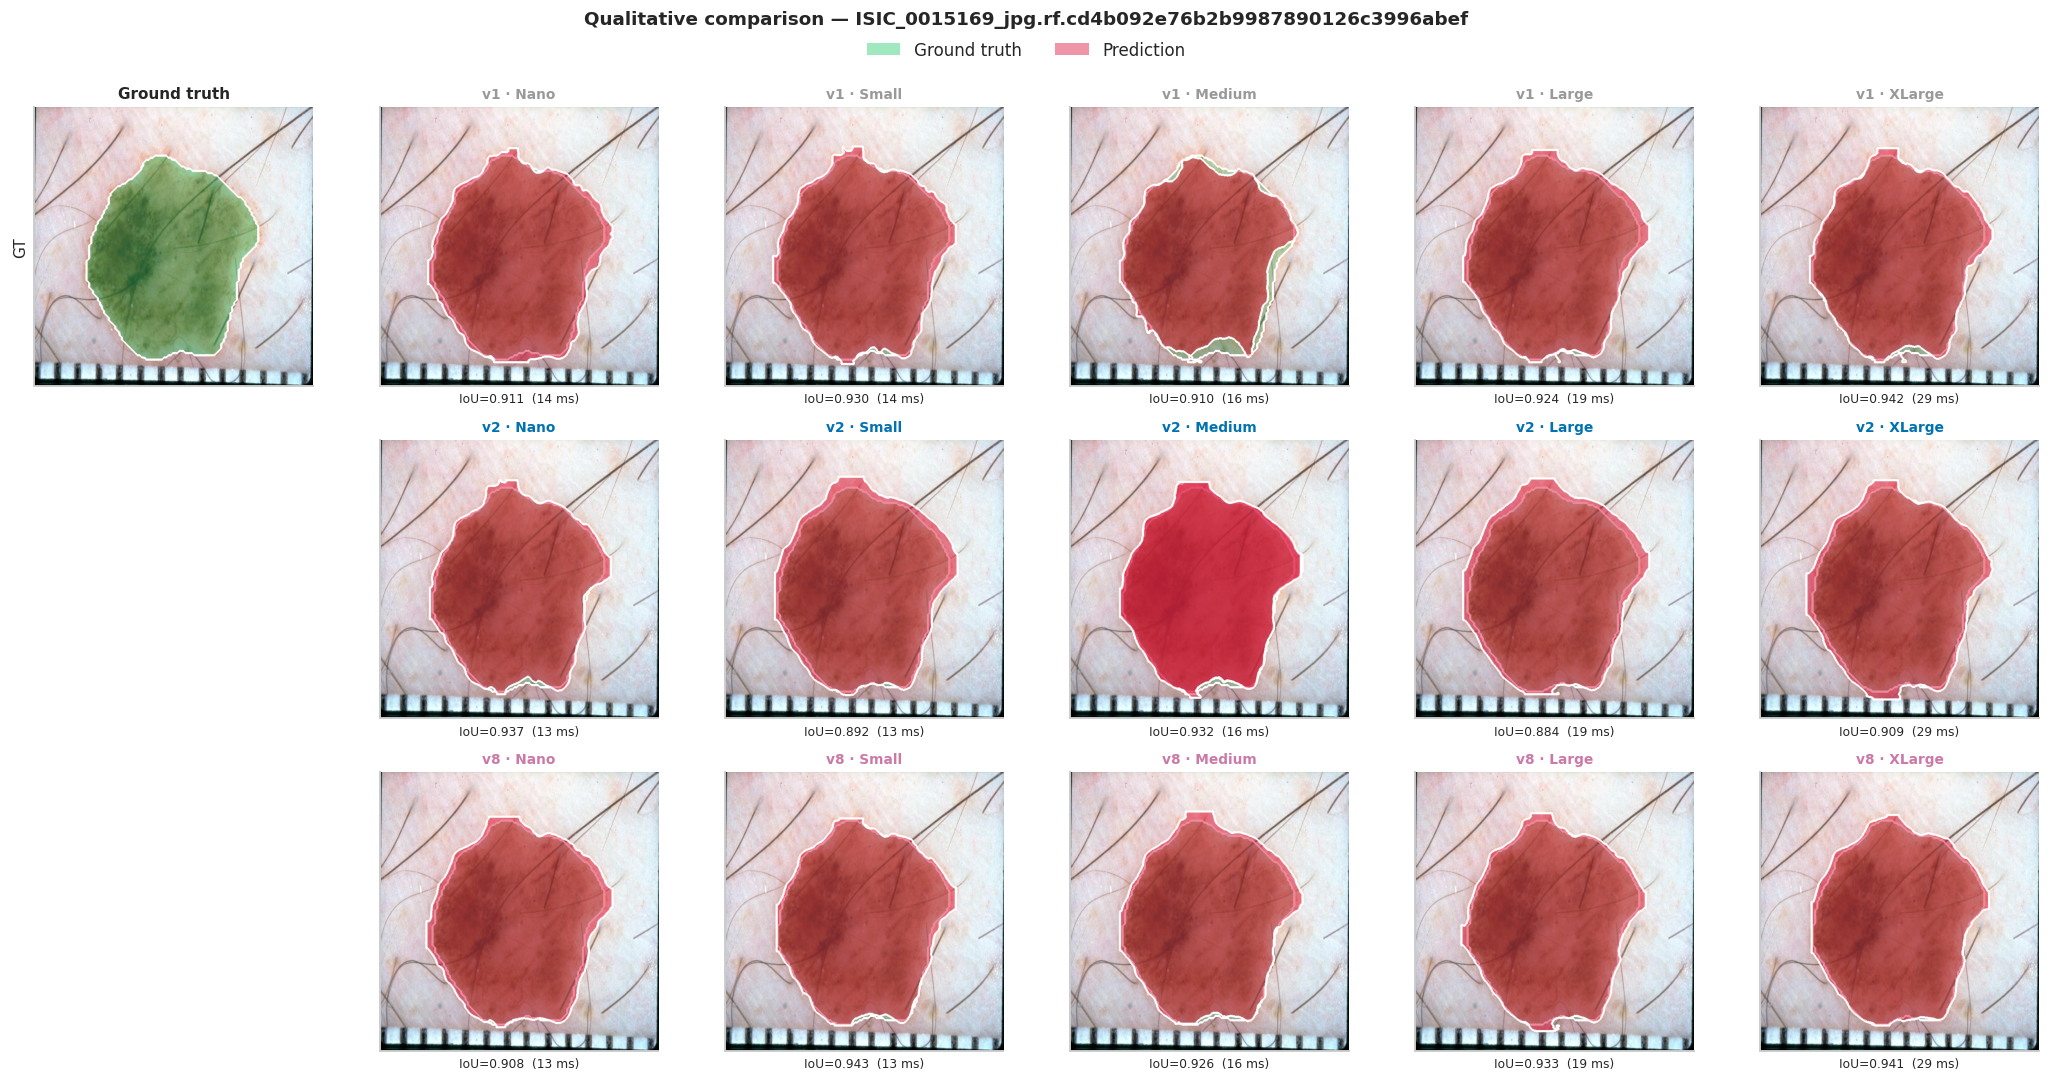

  saved: /home/antoniovinicius/projects/sandbox_yolo26/figures/qualitative/compare_models_ISIC_0015169_jpg.rf.cd4b092e76b2b9987890126c3996abef.png


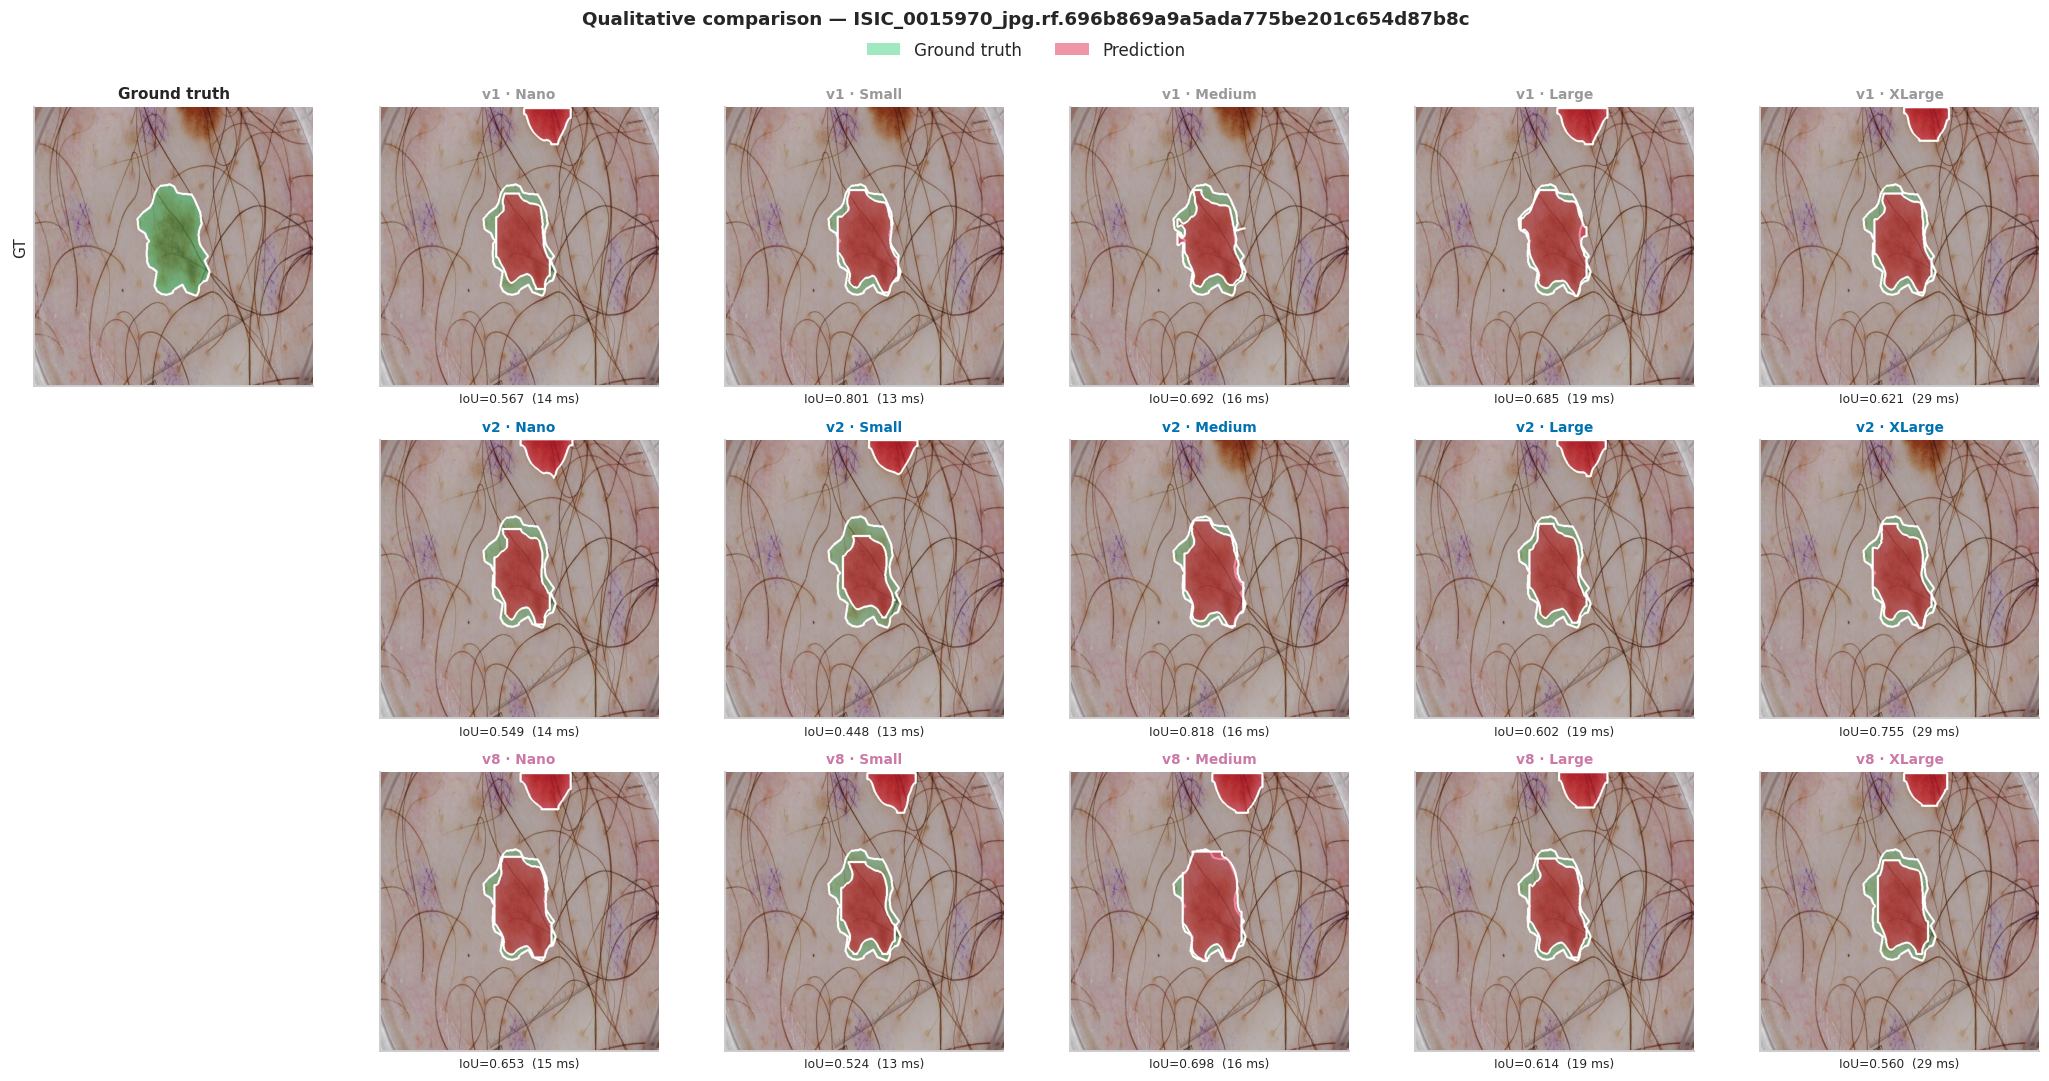

  saved: /home/antoniovinicius/projects/sandbox_yolo26/figures/qualitative/compare_models_ISIC_0015970_jpg.rf.696b869a9a5ada775be201c654d87b8c.png


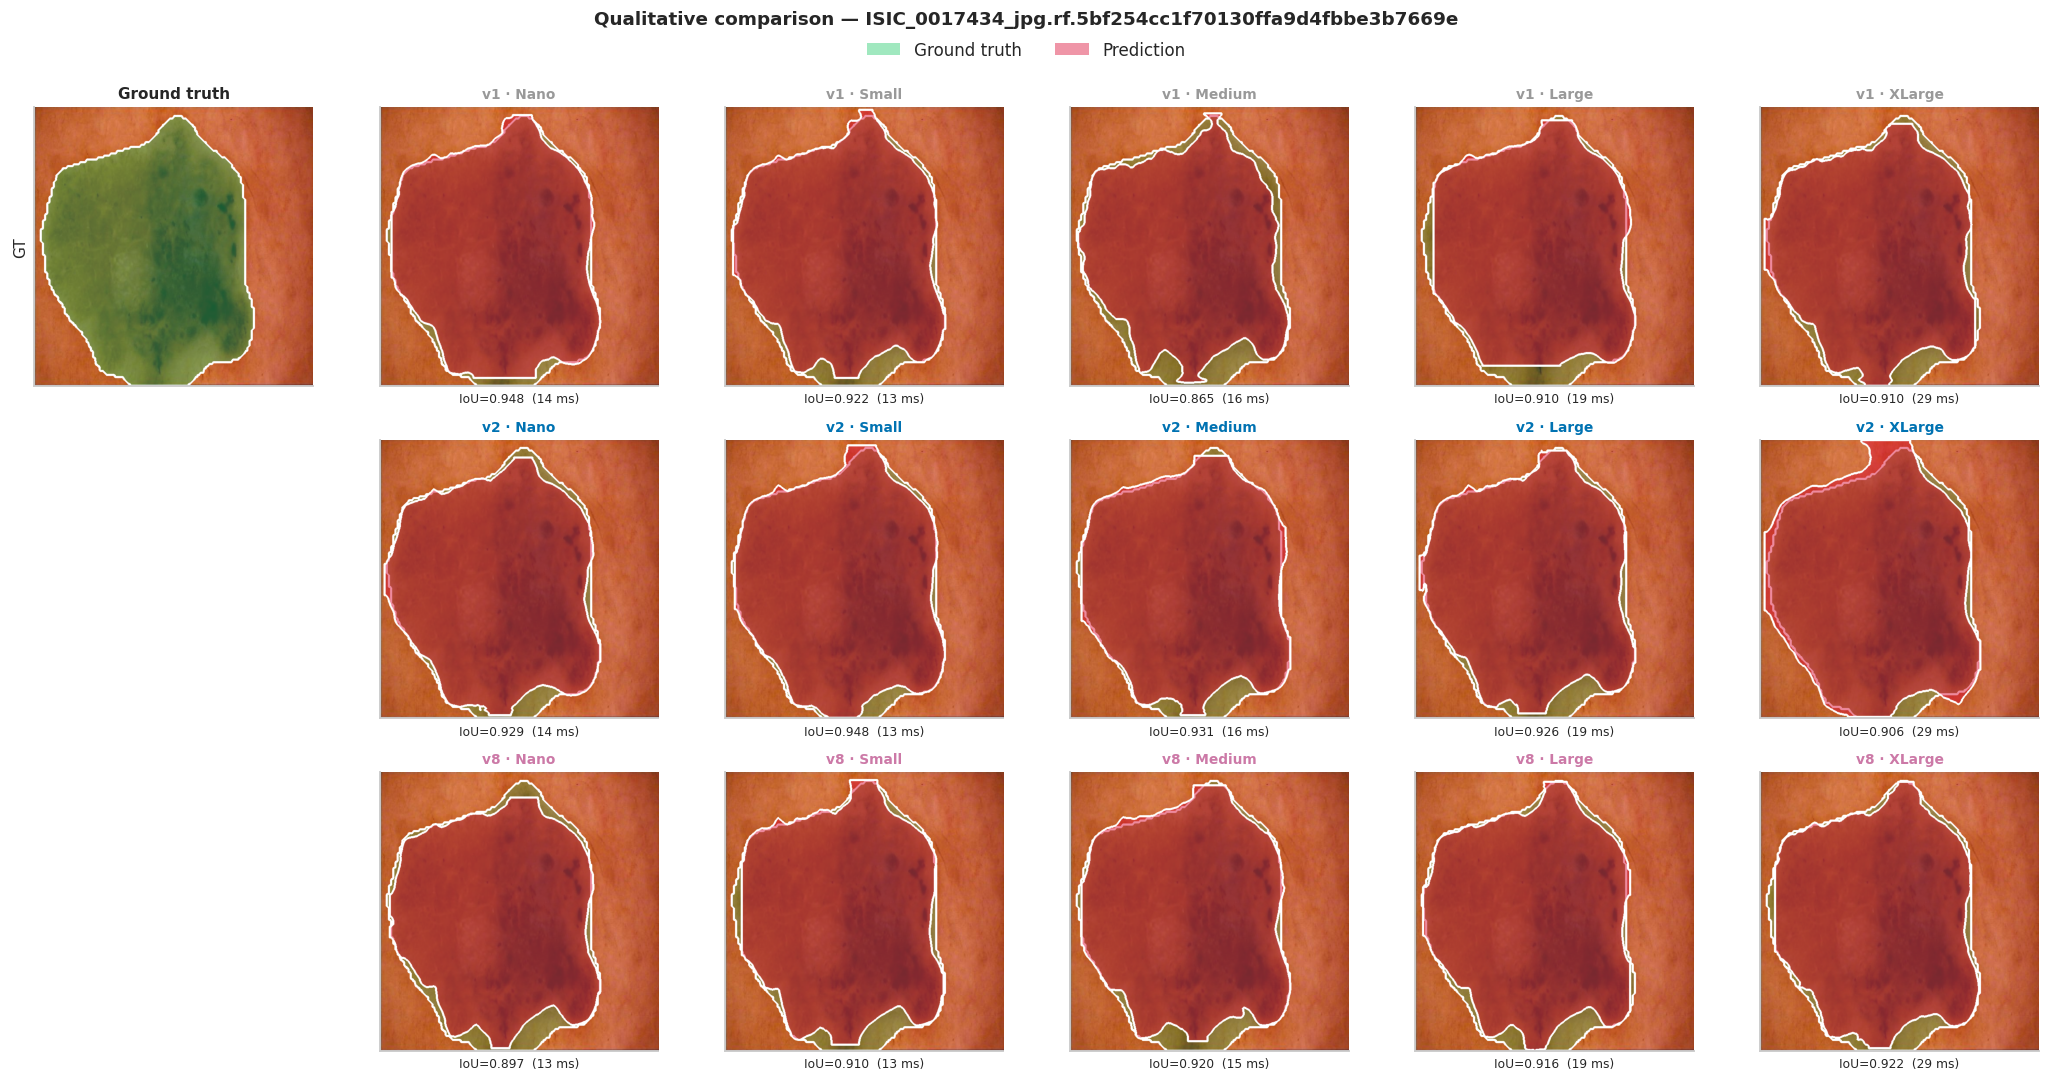

  saved: /home/antoniovinicius/projects/sandbox_yolo26/figures/qualitative/compare_models_ISIC_0017434_jpg.rf.5bf254cc1f70130ffa9d4fbbe3b7669e.png


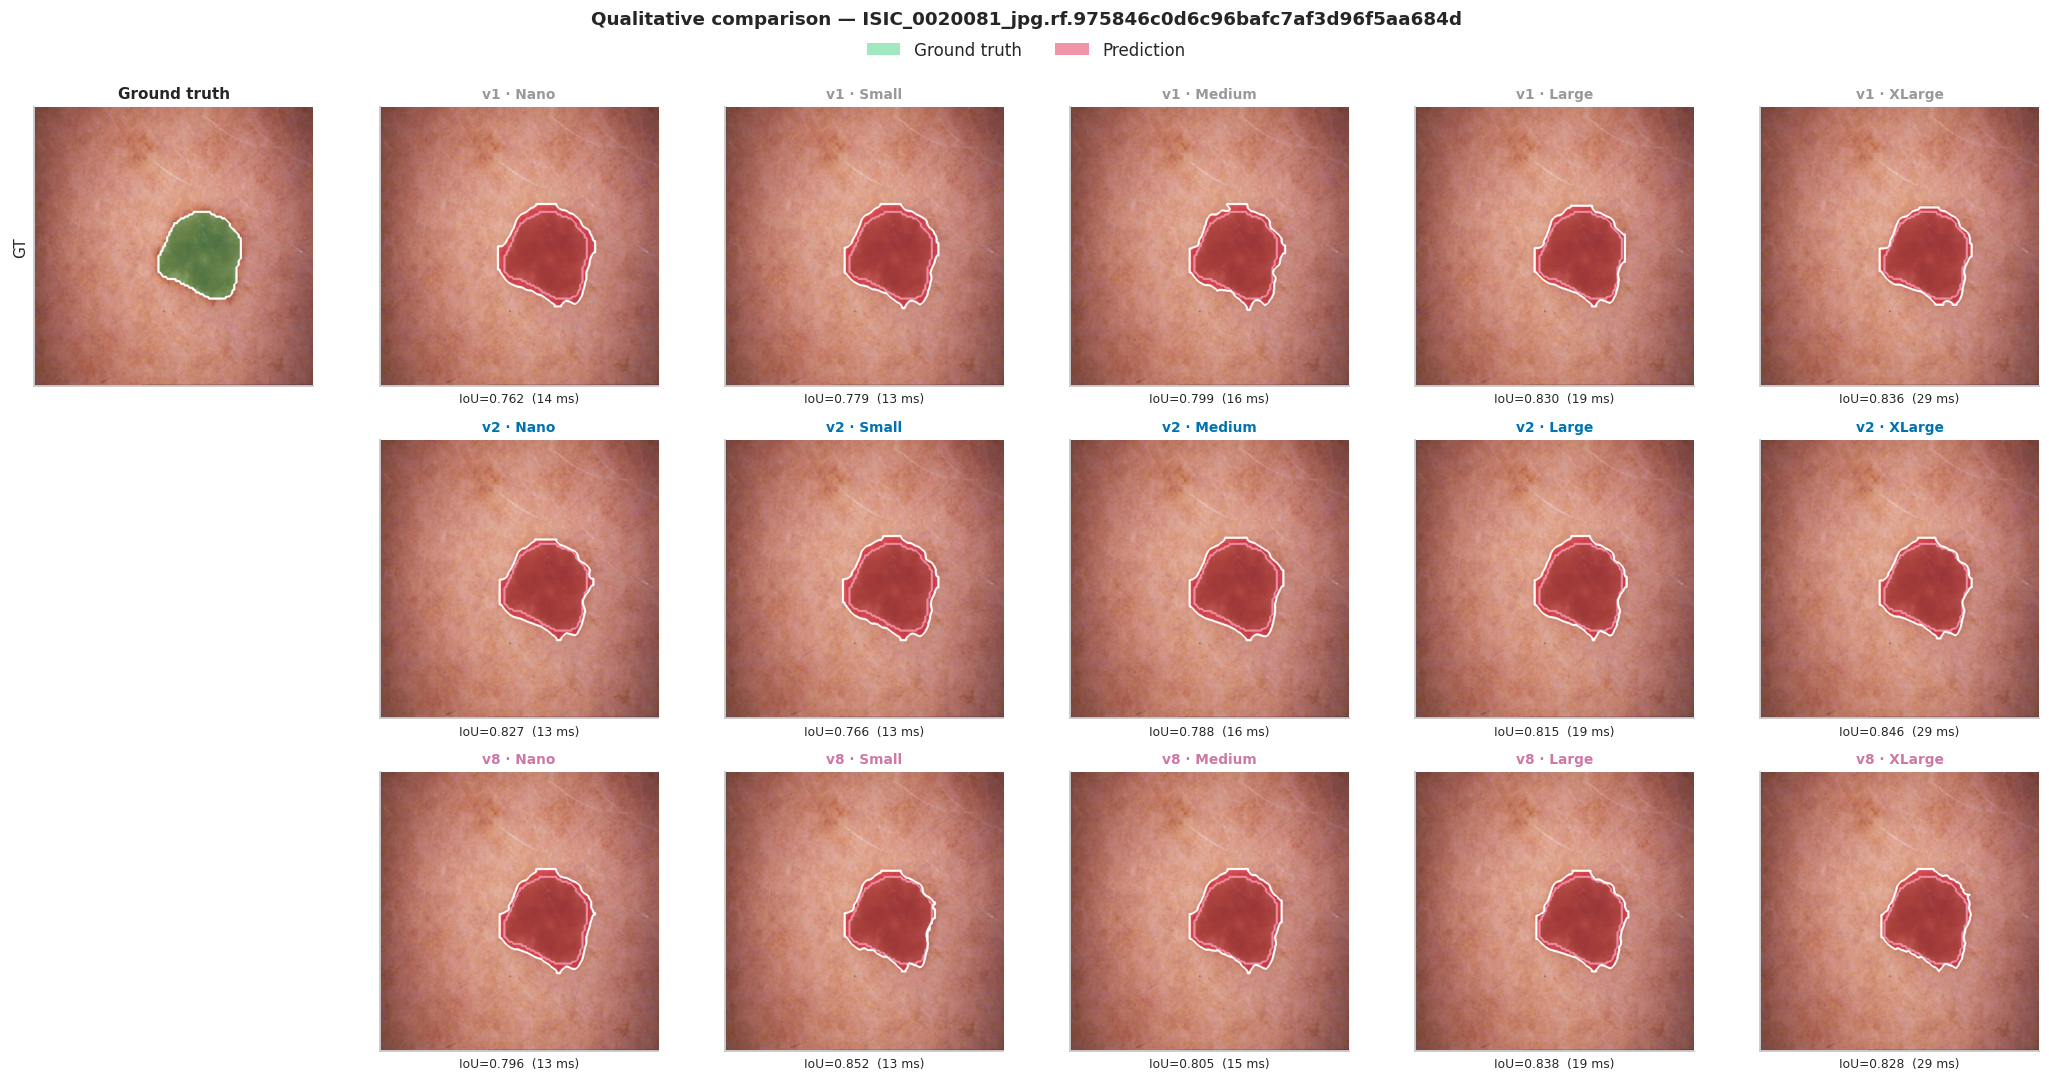

  saved: /home/antoniovinicius/projects/sandbox_yolo26/figures/qualitative/compare_models_ISIC_0020081_jpg.rf.975846c0d6c96bafc7af3d96f5aa684d.png


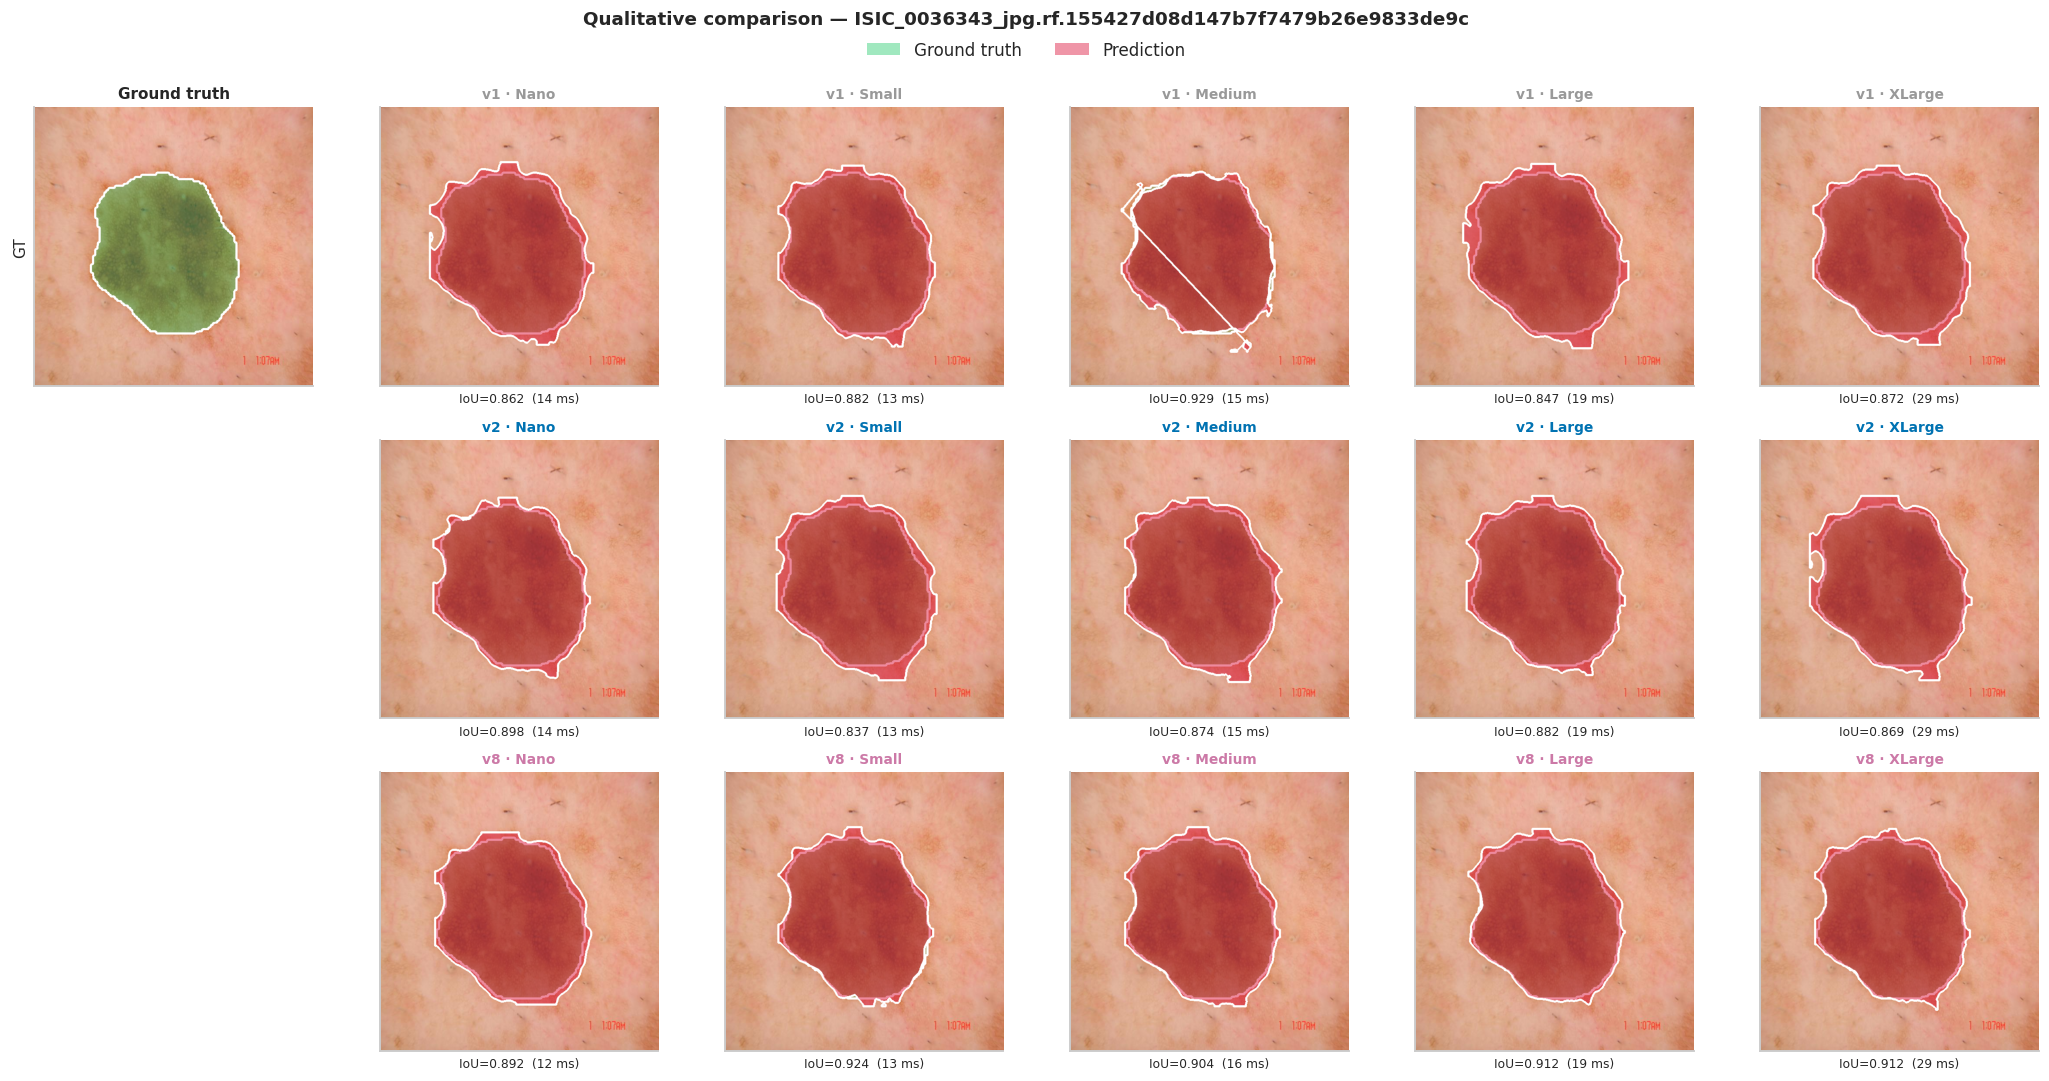

  saved: /home/antoniovinicius/projects/sandbox_yolo26/figures/qualitative/compare_models_ISIC_0036343_jpg.rf.155427d08d147b7f7479b26e9833de9c.png


In [128]:

try:
    import cv2
    from ultralytics import YOLO
    _qual_ok = True
except ImportError as e:
    print(f"OpenCV / Ultralytics não disponíveis: {e} — pulando seção qualitativa.")
    _qual_ok = False

import time

ALPHA = 0.45
COLOR_GT_BGR   = (113, 204,  46)   # lime green
COLOR_PRED_BGR = ( 60,  20, 220)   # crimson red
SAVE_DIR = BASE_DIR / "figures" / "qualitative"


def _read_gt_polys(label_path: Path, h: int, w: int):
    polys = []
    if label_path.exists():
        with label_path.open() as fh:
            for line in fh:
                parts = line.strip().split()
                if len(parts) > 1:
                    coords = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)
                    coords[:, 0] *= w
                    coords[:, 1] *= h
                    polys.append(coords.astype(np.int32))
    return polys


def _polys_to_mask(polys, h: int, w: int) -> np.ndarray:
    m = np.zeros((h, w), dtype=np.uint8)
    for p in polys:
        cv2.fillPoly(m, [p], 1)
    return m


def _iou(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter) / float(union) if union > 0 else float("nan")


def _draw_polys(img, polys, color_bgr, alpha=ALPHA, outline=(255, 255, 255)):
    for p in polys:
        ov = img.copy()
        cv2.fillPoly(ov, [p], color_bgr)
        cv2.addWeighted(ov, alpha, img, 1 - alpha, 0, img)
        cv2.polylines(img, [p], isClosed=True, color=outline, thickness=3,
                      lineType=cv2.LINE_8)


def _resolve_image(stem: str, img_dir: Path) -> Path | None:
    for ext in (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"):
        p = img_dir / f"{stem}{ext}"
        if p.exists():
            return p
    return None


def compare_qualitative_grid(image_stems, qual_grid, qual_versions, qual_models,
                             test_images_dir, test_labels_dir,
                             save_prefix: str = "compare_models"):
    """Render side-by-side qualitative comparison for grid (version × model)."""
    if not _qual_ok:
        return
    if not test_images_dir.exists():
        print(f"[SKIP] {test_images_dir} não encontrado — ajuste TEST_IMAGES_DIR")
        return
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

    # carrega modelos uma vez
    models = {}
    for key, wpath in qual_grid.items():
        if wpath.exists():
            try:
                models[key] = YOLO(str(wpath))
            except Exception as e:
                print(f"  [skip {key}] erro carregando {wpath}: {e}")

    if not models:
        print("[SKIP] nenhum best.pt utilizável.")
        return

    n_rows = len(qual_versions)
    n_cols = len(qual_models) + 1   # +1 para coluna do GT

    for stem in image_stems:
        img_path = _resolve_image(stem, test_images_dir)
        if img_path is None:
            print(f"[skip] imagem '{stem}' não encontrada em {test_images_dir}")
            continue
        lbl_path = test_labels_dir / f"{stem}.txt"

        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            print(f"[skip] cv2 não conseguiu ler {img_path}")
            continue
        h, w = img_bgr.shape[:2]
        gt_polys = _read_gt_polys(lbl_path, h, w)
        gt_mask  = _polys_to_mask(gt_polys, h, w)

        # GT panel (cantinho superior esquerdo)
        gt_canvas = img_bgr.copy()
        _draw_polys(gt_canvas, gt_polys, COLOR_GT_BGR)
        gt_rgb = cv2.cvtColor(gt_canvas, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(3.2 * n_cols, 3.2 * n_rows),
                                 squeeze=False)

        for i, v in enumerate(qual_versions):
            # primeira coluna = GT (replicado nas linhas? só na linha 0)
            ax_gt = axes[i, 0]
            if i == 0:
                ax_gt.imshow(gt_rgb)
                ax_gt.set_title("Ground truth", fontsize=10, fontweight="bold")
            else:
                ax_gt.axis("off")
            ax_gt.set_xticks([]); ax_gt.set_yticks([])
            if i == 0:
                ax_gt.set_ylabel("GT", fontsize=10)

            for j, m in enumerate(qual_models):
                ax = axes[i, j + 1]
                ax.set_xticks([]); ax.set_yticks([])
                key = (v, m)
                if key not in models:
                    ax.text(0.5, 0.5, "no weights",
                            ha="center", va="center", color="#888")
                    ax.set_title(f"{v} · {m}", fontsize=9)
                    continue
                t0 = time.time()
                try:
                    res = models[key](img_path, verbose=False, conf=0.25)[0]
                except Exception as e:
                    ax.text(0.5, 0.5, f"infer error\n{e}",
                            ha="center", va="center", color="red", fontsize=7)
                    ax.set_title(f"{v} · {m}", fontsize=9)
                    continue
                dt_ms = (time.time() - t0) * 1000.0

                pred_polys = []
                if res.masks is not None:
                    for poly in (res.masks.xy or []):
                        if poly.size:
                            pred_polys.append(poly.astype(np.int32))
                pred_mask = _polys_to_mask(pred_polys, h, w)
                iou = _iou(gt_mask, pred_mask) if gt_polys else float("nan")

                canvas = img_bgr.copy()
                _draw_polys(canvas, gt_polys,   COLOR_GT_BGR,   alpha=0.30)
                _draw_polys(canvas, pred_polys, COLOR_PRED_BGR, alpha=0.50)
                ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))

                title_color = VERSION_PALETTE.get(v, "#444")
                ax.set_title(f"{v} · {m}", fontsize=9, color=title_color,
                             fontweight="bold")
                ax.set_xlabel(f"IoU={iou:.3f}  ({dt_ms:.0f} ms)", fontsize=8)

        # legenda de cores (linhas: GT verde, predição vermelho)
        gt_patch  = Patch(facecolor=tuple(c / 255 for c in COLOR_GT_BGR[::-1]),
                          alpha=ALPHA, label="Ground truth")
        pr_patch  = Patch(facecolor=tuple(c / 255 for c in COLOR_PRED_BGR[::-1]),
                          alpha=ALPHA, label="Prediction")
        fig.legend(handles=[gt_patch, pr_patch], loc="upper center",
                   bbox_to_anchor=(0.5, 1.005), ncol=2)
        fig.suptitle(f"Qualitative comparison — {stem}",
                     y=1.02, fontsize=12, fontweight="bold")
        plt.tight_layout()
        out_path = SAVE_DIR / f"{save_prefix}_{stem}.png"
        plt.savefig(out_path, bbox_inches="tight", dpi=150)
        plt.show()
        print(f"  saved: {out_path}")


compare_qualitative_grid(
    IMAGE_STEMS, QUAL_GRID, QUAL_VERSIONS, QUAL_MODELS,
    TEST_IMAGES_DIR, TEST_LABELS_DIR,
    save_prefix="compare_models",
)


## 19. Export — tabela completa para CSV

In [129]:

export_cols = [
    "Version", "Model",
    "Mask mAP@50", "Mask mAP@50-95", "Mask Precision", "Mask Recall",
    "BBox mAP@50", "BBox mAP@50-95",
    "Best epoch", "Train time (min)",
    "Params (M)", "GFLOPs",
    "mAP / min", "mAP / M-param", "Quality/Cost",
    "Mask retention", "BBox retention",
    "Stability (std last10)", "Eps to 95% best", "Eps to 99% best",
    "Overfit gap (seg)", "Overfit gap (box)",
    "lr/pg0 start", "lr/pg0 mid", "lr/pg0 end",
    "optimizer", "lr0", "amp", "batch", "epochs (cfg)",
    "close_mosaic", "erasing", "weight_decay", "dropout",
]
export = df_long[export_cols].copy()

out_csv = BASE_DIR / "logs" / "compare_models_unified_summary.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
export.to_csv(out_csv, index=False)

print(f"Saved: {out_csv}  ({len(export)} rows × {export.shape[1]} cols)")
display(export.head(10))


Saved: /home/antoniovinicius/projects/sandbox_yolo26/logs/compare_models_unified_summary.csv  (15 rows × 34 cols)


,Version,Model,Mask mAP@50,Mask mAP@50-95,Mask Precision,Mask Recall,BBox mAP@50,BBox mAP@50-95,Best epoch,Train time (min),...,lr/pg0 end,optimizer,lr0,amp,batch,epochs (cfg),close_mosaic,erasing,weight_decay,dropout
0,v1,Nano,0.96166,0.69929,0.93813,0.90982,0.96374,0.64722,51,52.950167,...,0.000129,auto,0.010,True,16,100,10,0.4,0.0005,0.0
1,v1,Small,0.98759,0.71399,0.97878,0.97000,0.98828,0.68794,87,62.464000,...,0.000129,auto,0.010,True,16,100,10,0.4,0.0005,0.0
2,v1,Medium,0.97938,0.72751,0.92421,0.97554,0.96698,0.67411,99,113.767167,...,0.000129,auto,0.010,True,8,100,10,0.4,0.0005,0.0
3,v1,Large,0.97130,0.70034,0.97813,0.97000,0.98006,0.66534,73,115.312667,...,0.000129,auto,0.010,True,16,100,10,0.4,0.0005,0.0
4,v1,XLarge,0.96703,0.67507,0.88748,0.94648,0.94224,0.60042,27,129.224500,...,0.000763,auto,0.010,True,8,100,10,0.4,0.0005,0.0
5,v2,Nano,0.96408,0.72834,0.95865,0.92739,0.95286,0.69940,37,49.064000,...,0.001124,MuSGD,0.001,False,-1,100,10,0.4,0.0005,0.0
6,v2,Small,0.97881,0.71687,0.98944,0.93701,0.97755,0.67919,70,73.142833,...,0.000196,MuSGD,0.001,False,32,100,10,0.4,0.0005,0.0
7,v2,Medium,0.97736,0.67878,0.95945,0.94644,0.99058,0.66111,29,91.954500,...,0.002461,MuSGD,0.001,False,-1,100,10,0.4,0.0005,0.0
8,v2,Large,0.98681,0.72370,0.95113,0.96000,0.98681,0.68914,22,244.218333,...,0.000905,MuSGD,0.001,False,-1,100,10,0.4,0.0005,0.0
9,v2,XLarge,0.96809,0.70434,0.96772,0.89928,0.97693,0.68263,17,281.373333,...,0.001996,MuSGD,0.001,False,-1,100,10,0.4,0.0005,0.0
